# EUR/USD Time Series Forecasting with Neural Networks
**Financial Data Analytics — Part B**

This notebook performs end-to-end time series forecasting on EUR/USD 5-minute data
using three different data configurations:

| Run | Data Used | Purpose |
|-----|-----------|---------|
| **Run 1** | Bid prices only | Single-stream baseline |
| **Run 2** | Ask prices only | Single-stream baseline |
| **Run 3** | Bid + Ask combined | Mid-price, spread & microstructure features |

Each run trains the same four neural network architectures:
**Dense (MLP) · LSTM · GRU (with hyperparameter search) · Transformer Encoder**

The three-run design experimentally proves whether combining both price streams
produces measurably better forecasts than using either stream alone.


## Section 1 — Imports & Configuration

In [1]:
# Import all libraries needed for data handling, neural network
#       construction, training, and visualisation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import types

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# WHAT: Fix random seeds for Python, NumPy, and PyTorch, and select
#       the compute device (GPU if available, otherwise CPU).
# WHY:  Neural network weights are randomly initialised. Without a fixed
#       seed, results differ on every run making it impossible to reproduce
#       or fairly compare experiments. GPU acceleration (CUDA) can reduce
#       training time from hours to minutes on sequence models.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
# WHAT: Define all hyperparameters and file paths in one central block.
# WHY:  Centralising configuration means any value (epochs, patience,
#       window size) only needs to be changed in one place. This prevents
#       inconsistencies where one run accidentally trains longer than
#       another, which would make the three-run comparison unfair.
# HOW:  Constants are written in UPPER_CASE by Python convention.
#       WINDOW_SIZE defines how many past 5-minute bars form one input
#       sample. EPOCHS and PATIENCE together control early stopping.

# -- File paths -----------------------------------------------------------
BID_PATH = "/kaggle/input/datasets/jennifersangwan/eur-usd-ask-bid-data/EURUSD_5 Mins_Bid_2025.10.01_2026.03.31.csv"
ASK_PATH = "/kaggle/input/datasets/jennifersangwan/eur-usd-ask-bid-data/EURUSD_5 Mins_Ask_2025.10.01_2026.03.31.csv"

# -- Hyperparameters ------------------------------------------------------
WINDOW_SIZE   = 20
BATCH_SIZE    = 64
EPOCHS        = 50
PATIENCE      = 15
LEARNING_RATE = 1e-3

print(f"Window: {WINDOW_SIZE} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | "
      f"Patience: {PATIENCE} | LR: {LEARNING_RATE}")


Window: 20 | Batch: 64 | Epochs: 50 | Patience: 15 | LR: 0.001


## Section 2 — Data Loading & Bid/Ask Combination

In [4]:
# WHAT: Load both Bid and Ask CSV files from Dukascopy and immediately
#       strip whitespace from all column names.
# WHY:  Dukascopy exports column names with trailing spaces (e.g.
#       "Volume " instead of "Volume"). Without stripping, pandas
#       falls back to auto-suffixing columns as "Volume _x" and
#       "Volume _y" after the merge, causing KeyError on access.
# HOW:  str.strip() removes leading and trailing whitespace from every
#       column name in one vectorised operation immediately after loading.

df_bid = pd.read_csv(BID_PATH)
df_ask = pd.read_csv(ASK_PATH)

df_bid.columns = df_bid.columns.str.strip()
df_ask.columns = df_ask.columns.str.strip()

print("Bid shape:", df_bid.shape, "| Columns:", df_bid.columns.tolist())
print("Ask shape:", df_ask.shape, "| Columns:", df_ask.columns.tolist())


Bid shape: (36984, 6) | Columns: ['Time (EET)', 'Open', 'High', 'Low', 'Close', 'Volume']
Ask shape: (36984, 6) | Columns: ['Time (EET)', 'Open', 'High', 'Low', 'Close', 'Volume']


In [5]:
# WHAT: Parse the Time column as datetime, rename OHLCV columns with
#       Bid/Ask prefixes, and inner-join both DataFrames on timestamp.
# WHY:  Prefixing columns before the merge prevents name collisions and
#       makes it unambiguous which stream each column belongs to after
#       the join. An inner join keeps only timestamps present in both
#       files, avoiding NaN values from bars missing in one stream.
#       Chronological sorting is required for the time-based split later.
# HOW:  pd.to_datetime() converts string timestamps to datetime objects.
#       rename() applies a column mapping dictionary. pd.merge with
#       how="inner" matches rows by the shared Time key.

df_bid = df_bid.rename(columns={"Time (EET)": "Time"})
df_ask = df_ask.rename(columns={"Time (EET)": "Time"})

df_bid["Time"] = pd.to_datetime(df_bid["Time"])
df_ask["Time"] = pd.to_datetime(df_ask["Time"])

df_bid = df_bid.rename(columns={"Open": "Bid_Open", "High": "Bid_High",
                                  "Low": "Bid_Low",  "Close": "Bid_Close",
                                  "Volume": "Bid_Volume"})
df_ask = df_ask.rename(columns={"Open": "Ask_Open", "High": "Ask_High",
                                  "Low": "Ask_Low",  "Close": "Ask_Close",
                                  "Volume": "Ask_Volume"})

df = pd.merge(df_bid, df_ask, on="Time", how="inner")
df = df.sort_values("Time").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Time range:", df["Time"].min(), "→", df["Time"].max())
df.head(3)


Merged shape: (36984, 11)
Time range: 2025-10-01 00:00:00 → 2026-03-31 23:55:00


,Time,Bid_Open,Bid_High,Bid_Low,Bid_Close,Bid_Volume,Ask_Open,Ask_High,Ask_Low,Ask_Close,Ask_Volume
0,2025-10-01 00:00:00,1.17325,1.17339,1.17325,1.17339,34.53,1.17347,1.17398,1.17347,1.17387,25.17
1,2025-10-01 00:05:00,1.17341,1.17350,1.17338,1.17343,33.60,1.17387,1.17397,1.17385,1.17386,18.73
2,2025-10-01 00:10:00,1.17343,1.17348,1.17328,1.17335,103.47,1.17392,1.17392,1.17352,1.17384,37.35


In [6]:
# WHAT: Derive mid-prices, the bid-ask spread in pips, and combined
#       volume from the two price streams.
# WHY:  The mid-price (average of Bid and Ask) is the fairest estimate
#       of the true market price because it is not biased toward either
#       buyer or seller. The spread (Ask minus Bid) measures market
#       liquidity directly — a widening spread signals lower liquidity
#       and higher uncertainty, making it a predictive signal in its own
#       right. For EUR/USD, multiplying by 10,000 converts the decimal
#       spread to the conventional pip unit used by traders.
#       These derived columns are only used in Run 3 (Combined).
# HOW:  Element-wise arithmetic on pandas Series.
#       spread_pct = (Ask_Close - Bid_Close) / Mid_Close × 10000.

df["Mid_Open"]     = (df["Bid_Open"]  + df["Ask_Open"])  / 2
df["Mid_High"]     = (df["Bid_High"]  + df["Ask_High"])  / 2
df["Mid_Low"]      = (df["Bid_Low"]   + df["Ask_Low"])   / 2
df["Mid_Close"]    = (df["Bid_Close"] + df["Ask_Close"]) / 2
df["spread"]       = df["Ask_Close"]  - df["Bid_Close"]
df["spread_pct"]   = df["spread"] / df["Mid_Close"] * 10000
df["total_volume"] = df["Bid_Volume"] + df["Ask_Volume"]

print("Mid-price and spread columns created.")
df[["Mid_Close", "spread", "spread_pct", "total_volume"]].describe().round(6)


Mid-price and spread columns created.


,Mid_Close,spread,spread_pct,total_volume
count,36984.000000,36984.000000,36984.000000,36984.000000
mean,1.167163,0.000049,0.418725,791.799421
std,0.011636,0.000082,0.697042,737.414854
min,1.141140,0.000010,0.083091,0.000000
25%,1.158700,0.000020,0.172870,318.135000
50%,1.164810,0.000040,0.338427,583.685000
75%,1.175445,0.000050,0.425336,1024.297500
max,1.205610,0.002540,21.556846,10354.020000


## Section 3 — Exploratory Data Analysis

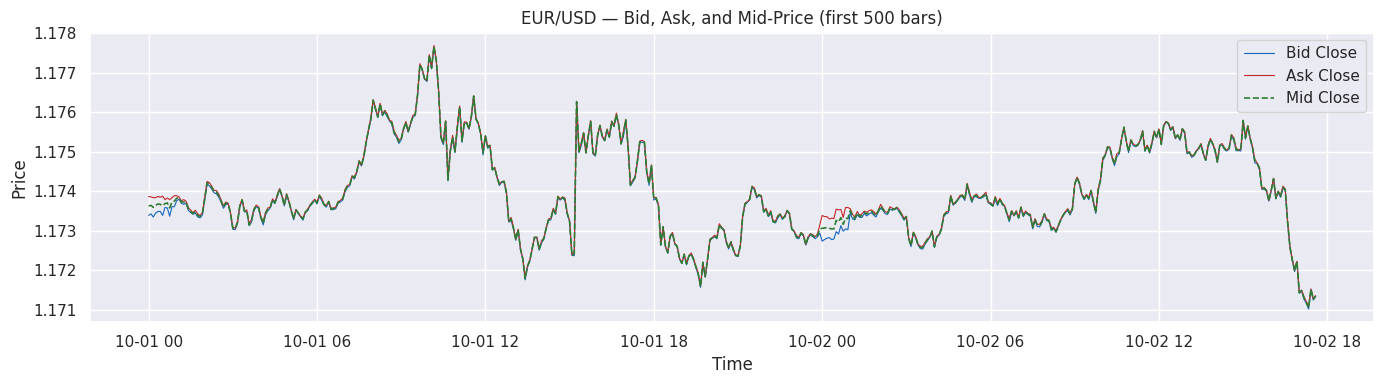

In [7]:
# WHAT: Plot Bid Close, Ask Close, and Mid Close on a shared axis to
#       visualise the three price series and the gap between them.
# WHY:  Overlaying all three price streams makes the spread visible as
#       the gap between the Bid (lower) and Ask (upper) lines, with Mid
#       sitting exactly between them. This directly motivates Run 3 —
#       the mid-price is a cleaner, unbiased series that neither Bid-only
#       nor Ask-only captures fully.
# HOW:  Three plot() calls on the same axes. The first 500 bars are
#       shown so the spread gap is visible without the lines merging.

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["Time"].iloc[:500], df["Bid_Close"].iloc[:500],
        color="#1565C0", lw=0.8, label="Bid Close")
ax.plot(df["Time"].iloc[:500], df["Ask_Close"].iloc[:500],
        color="#C62828", lw=0.8, label="Ask Close")
ax.plot(df["Time"].iloc[:500], df["Mid_Close"].iloc[:500],
        color="#2E7D32", lw=1.2, linestyle="--", label="Mid Close")
ax.set_title("EUR/USD — Bid, Ask, and Mid-Price (first 500 bars)")
ax.set_xlabel("Time"); ax.set_ylabel("Price"); ax.legend()
plt.tight_layout(); plt.show()


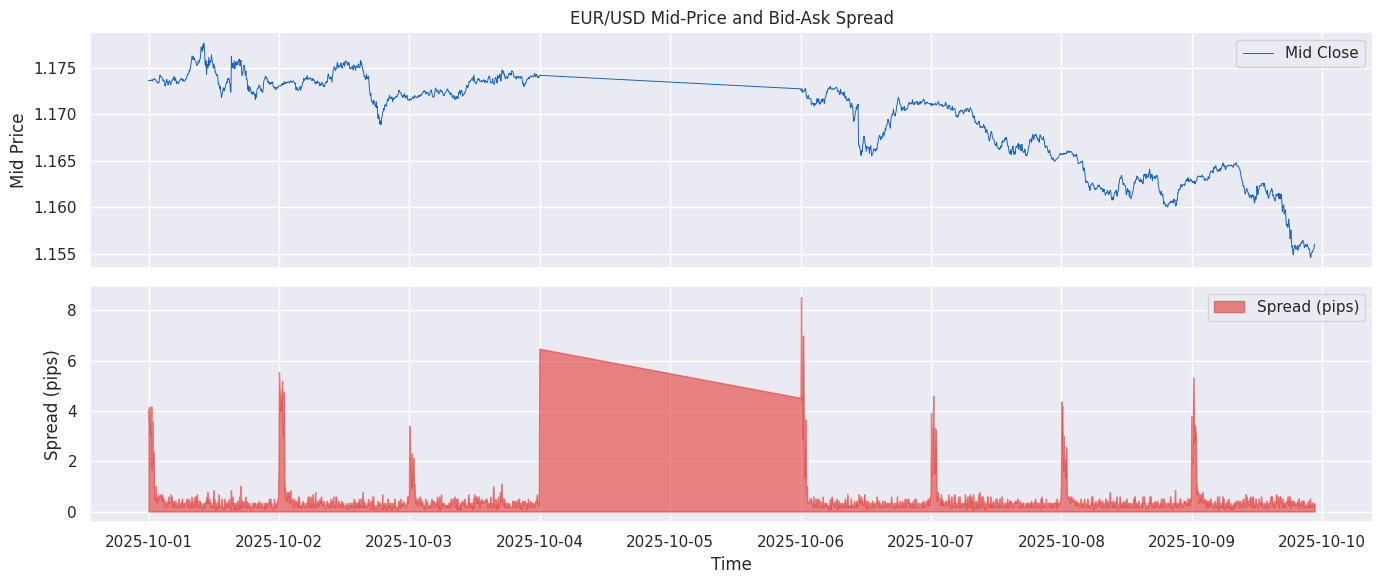

In [8]:
# WHAT: Plot the bid-ask spread in pips over time alongside the mid-price.
# WHY:  Spread is not constant — it widens during low-liquidity periods
#       such as the Asian session, news events, and market open/close.
#       Understanding spread behaviour confirms it carries independent
#       information beyond what either Bid or Ask alone provides, which
#       motivates including spread_pct as a feature in Run 3.
# HOW:  Two vertically stacked subplots share the x-axis (sharex=True).
#       fill_between shades the spread area for visual clarity.

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df["Time"].iloc[:2000], df["Mid_Close"].iloc[:2000],
             color="#1565C0", lw=0.7, label="Mid Close")
axes[0].set_ylabel("Mid Price"); axes[0].legend()
axes[0].set_title("EUR/USD Mid-Price and Bid-Ask Spread")

axes[1].fill_between(df["Time"].iloc[:2000], df["spread_pct"].iloc[:2000],
                     color="#E53935", alpha=0.6, label="Spread (pips)")
axes[1].set_ylabel("Spread (pips)"); axes[1].set_xlabel("Time"); axes[1].legend()
plt.tight_layout(); plt.show()


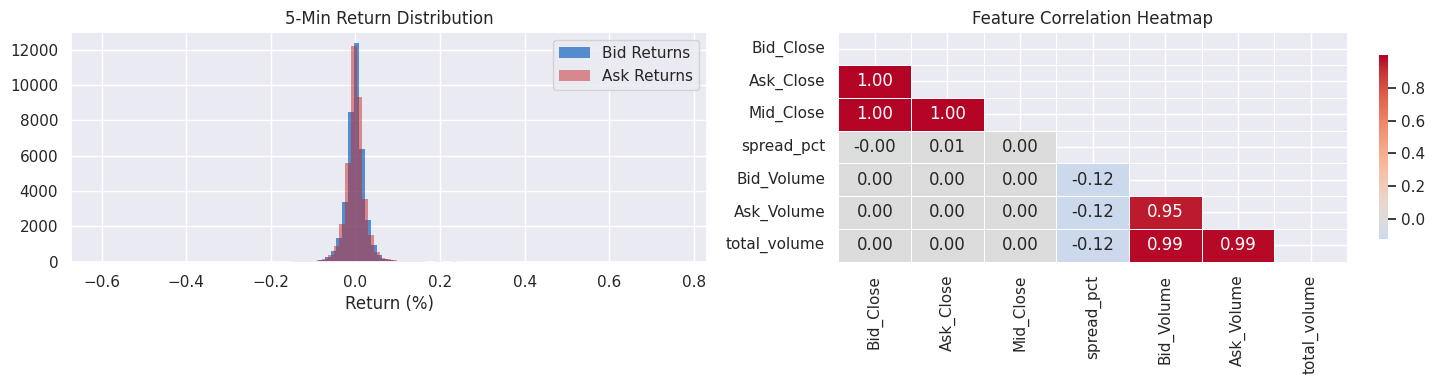

In [9]:
# WHAT: Plot return distributions and a correlation heatmap for the
#       key columns from both streams.
# WHY:  Return distributions reveal whether the target variable is
#       approximately normally distributed (as assumed by MSE loss) or
#       has fat tails. The heatmap shows which features carry redundant
#       information versus independent signals. High correlation between
#       Bid and Ask columns confirms they are similar but not identical —
#       their difference (the spread) is the unique information gained
#       by combining both streams.
# HOW:  pct_change() computes bar-over-bar returns. A lower-triangular
#       heatmap masks the upper triangle to avoid showing each pair twice.

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(df["Bid_Close"].pct_change().dropna() * 100, bins=100,
             color="#1565C0", alpha=0.7, label="Bid Returns", edgecolor="none")
axes[0].hist(df["Ask_Close"].pct_change().dropna() * 100, bins=100,
             color="#C62828", alpha=0.5, label="Ask Returns", edgecolor="none")
axes[0].set_title("5-Min Return Distribution"); axes[0].set_xlabel("Return (%)")
axes[0].legend()

corr_cols = ["Bid_Close","Ask_Close","Mid_Close","spread_pct",
             "Bid_Volume","Ask_Volume","total_volume"]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1], linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("Feature Correlation Heatmap")
plt.tight_layout(); plt.show()


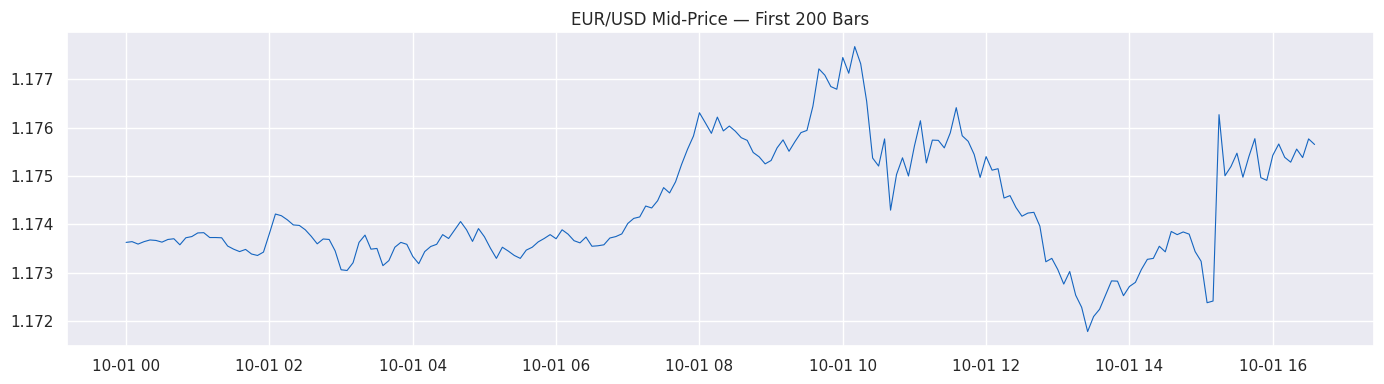

In [10]:
# WHAT: Display a candlestick chart of the mid-price for the first 200 bars.
# WHY:  Candlestick charts are the standard price visualisation in financial
#       markets. Each candle encodes Open, High, Low, and Close into a
#       single glyph, making trend direction, volatility, and price
#       rejection patterns visible at a glance. This satisfies the
#       assignment requirement for Japanese candlestick pattern visualisation.
# HOW:  mplfinance.plot() accepts a DataFrame with OHLCV columns indexed
#       by datetime. A plain line fallback is used if mplfinance is absent.

try:
    import mplfinance as mpf
    df_candle = df.set_index("Time")[["Mid_Open","Mid_High","Mid_Low",
                                      "Mid_Close","total_volume"]].iloc[:200].copy()
    df_candle.columns = ["Open","High","Low","Close","Volume"]
    df_candle.index.name = "Date"
    mpf.plot(df_candle, type="candle", volume=True, style="charles",
             title="EUR/USD Mid-Price — First 200 Bars (5-min)",
             ylabel="Price", ylabel_lower="Volume", figsize=(14, 6))
except ImportError:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["Time"].iloc[:200], df["Mid_Close"].iloc[:200],
            color="#1565C0", lw=0.8)
    ax.set_title("EUR/USD Mid-Price — First 200 Bars")
    plt.tight_layout(); plt.show()


## Section 4 — Feature Engineering for All Three Runs

Three separate feature sets are constructed:
- **Bid-only**: all technical indicators computed from Bid OHLCV columns
- **Ask-only**: same indicators computed from Ask OHLCV columns
- **Combined**: mid-price indicators plus spread and microstructure features


In [11]:
# WHAT: Define a reusable function that engineers all technical indicators
#       from a given set of OHLCV column names.
# WHY:  The same indicator logic (moving averages, RSI, volatility, candle
#       structure) applies to Bid, Ask, and Mid prices. A single function
#       avoids writing identical code three times and ensures the only
#       difference between Run 1 and Run 2 feature sets is the input
#       price stream — all indicator parameters are held constant.
# HOW:  The function accepts a DataFrame and the names of the Open, High,
#       Low, Close, and Volume columns for that stream. It computes all
#       indicators using those columns and returns a list of new column
#       names and a DataFrame with those columns added. A prefix argument
#       namespaces the new columns so Bid and Ask indicators do not clash.

def engineer_features(df, open_col, high_col, low_col, close_col,
                      volume_col, prefix, target_col_name):

    p = prefix   # short alias for column naming

    # -- Returns and log returns ------------------------------------------
    # Log returns are stationary and approximately normally distributed,
    # making them better inputs than raw prices for neural networks.
    # The target is the NEXT bar's percentage return (shift(-1) aligns it).
    df[f"{p}_log_ret"]  = np.log(df[close_col] / df[close_col].shift(1))
    df[target_col_name] = df[close_col].pct_change().shift(-1)

    # -- Candle structure -------------------------------------------------
    # Range, body, and wicks encode price action within each bar.
    # They capture information that raw OHLC prices do not, since OHLC
    # values are highly correlated with each other.
    df[f"{p}_range"]      = df[high_col]  - df[low_col]
    df[f"{p}_body"]       = df[close_col] - df[open_col]
    df[f"{p}_upper_wick"] = df[high_col]  - df[[open_col, close_col]].max(axis=1)
    df[f"{p}_lower_wick"] = df[[open_col, close_col]].min(axis=1) - df[low_col]

    # -- Moving averages and crossover ------------------------------------
    # MAs smooth noise and reveal trend direction. The crossover between
    # fast (5) and slow (10) MAs is a widely used momentum signal.
    df[f"{p}_ma5"]    = df[close_col].rolling(5).mean()
    df[f"{p}_ma10"]   = df[close_col].rolling(10).mean()
    df[f"{p}_ma20"]   = df[close_col].rolling(20).mean()
    df[f"{p}_cross"]  = df[f"{p}_ma5"] - df[f"{p}_ma10"]

    # -- Rolling volatility -----------------------------------------------
    # Realised volatility lets the model detect regime changes between
    # calm and turbulent market conditions.
    df[f"{p}_vol5"]   = df[f"{p}_log_ret"].rolling(5).std()
    df[f"{p}_vol10"]  = df[f"{p}_log_ret"].rolling(10).std()

    # -- RSI-14 -----------------------------------------------------------
    # RSI is a momentum oscillator (0–100). Values >70 suggest overbought
    # conditions; <30 suggest oversold. It encodes mean-reversion signals
    # that would take many raw bars for the model to detect implicitly.
    delta = df[close_col].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df[f"{p}_rsi14"]  = 100 - (100 / (1 + gain / (loss + 1e-8)))

    # -- Volume feature ---------------------------------------------------
    df[f"{p}_volume"] = df[volume_col]

    feature_cols = [
        open_col, high_col, low_col, close_col,
        f"{p}_log_ret", f"{p}_range", f"{p}_body",
        f"{p}_upper_wick", f"{p}_lower_wick",
        f"{p}_ma5", f"{p}_ma10", f"{p}_ma20", f"{p}_cross",
        f"{p}_vol5", f"{p}_vol10", f"{p}_rsi14", f"{p}_volume"
    ]

    return feature_cols


print("Feature engineering function defined.")


Feature engineering function defined.


In [12]:
# WHAT: Build the Bid-only feature set (Run 1).
# WHY:  Using only Bid columns establishes the single-stream baseline.
#       All technical indicators are computed from Bid prices so the
#       feature set is self-consistent and representative of what a
#       model would have access to if only Bid data were available.
# HOW:  engineer_features() is called with Bid column names and prefix "B".
#       After computing indicators, rows with NaN (from rolling windows
#       and the shifted target) are dropped.

bid_features = engineer_features(
    df,
    open_col="Bid_Open", high_col="Bid_High",
    low_col="Bid_Low",   close_col="Bid_Close",
    volume_col="Bid_Volume", prefix="B",
    target_col_name="target_bid"
)

df_bid_clean = df.dropna(subset=bid_features + ["target_bid"]).reset_index(drop=True)
print(f"Bid-only: {len(df_bid_clean):,} rows | {len(bid_features)} features")
print("Features:", bid_features)


Bid-only: 36,964 rows | 17 features
Features: ['Bid_Open', 'Bid_High', 'Bid_Low', 'Bid_Close', 'B_log_ret', 'B_range', 'B_body', 'B_upper_wick', 'B_lower_wick', 'B_ma5', 'B_ma10', 'B_ma20', 'B_cross', 'B_vol5', 'B_vol10', 'B_rsi14', 'B_volume']


In [13]:
# WHAT: Build the Ask-only feature set (Run 2).
# WHY:  Using only Ask columns provides the second single-stream baseline.
#       Ask prices are consistently higher than Bid by the spread amount.
#       If the model learns the same patterns from Ask as from Bid, it
#       confirms that the spread (their difference) is the unique
#       information that requires both streams.
# HOW:  Same engineer_features() call with Ask column names and prefix "A".

ask_features = engineer_features(
    df,
    open_col="Ask_Open", high_col="Ask_High",
    low_col="Ask_Low",   close_col="Ask_Close",
    volume_col="Ask_Volume", prefix="A",
    target_col_name="target_ask"
)

df_ask_clean = df.dropna(subset=ask_features + ["target_ask"]).reset_index(drop=True)
print(f"Ask-only: {len(df_ask_clean):,} rows | {len(ask_features)} features")


Ask-only: 36,964 rows | 17 features


In [14]:
# WHAT: Build the Combined (Bid + Ask) feature set (Run 3).
# WHY:  The combined set adds features that neither stream can provide
#       alone: mid-price (unbiased fair value), spread (liquidity signal),
#       spread in pips, spread lags (recent liquidity trend), and the
#       bid/ask volume ratio (order flow imbalance). These microstructure
#       features encode market conditions that are invisible in single-
#       stream data, which is the core hypothesis being tested by
#       running all three configurations.
# HOW:  engineer_features() is called on mid-price columns (prefix "M").
#       Additional spread and microstructure columns are appended to the
#       feature list manually, then the combined DataFrame is cleaned.

combined_features = engineer_features(
    df,
    open_col="Mid_Open", high_col="Mid_High",
    low_col="Mid_Low",   close_col="Mid_Close",
    volume_col="total_volume", prefix="M",
    target_col_name="target_mid"
)

# Add spread lag features — carry information about recent liquidity trends
df["spread_lag1"]  = df["spread_pct"].shift(1)
df["spread_lag2"]  = df["spread_pct"].shift(2)
# Volume ratio — measures order flow imbalance between buyers and sellers
df["vol_ratio"]    = df["Bid_Volume"] / (df["Ask_Volume"] + 1e-8)

extra_combined = ["spread", "spread_pct", "spread_lag1", "spread_lag2",
                  "total_volume", "vol_ratio"]
combined_features += extra_combined

df_comb_clean = df.dropna(
    subset=combined_features + ["target_mid"]).reset_index(drop=True)
print(f"Combined: {len(df_comb_clean):,} rows | {len(combined_features)} features")
print("Extra features over single-stream:", extra_combined)


Combined: 36,964 rows | 23 features
Extra features over single-stream: ['spread', 'spread_pct', 'spread_lag1', 'spread_lag2', 'total_volume', 'vol_ratio']


## Section 5 — Shared Pipeline Functions

In [15]:
# WHAT: Define a function that splits a cleaned DataFrame into
#       train/val/test sets in strict chronological order.
# WHY:  Financial time series must never be split randomly. Random
#       splitting would allow future data to leak into training,
#       producing deceptively low error metrics that do not reflect
#       real-world performance. Strict chronological splitting ensures
#       the model is always evaluated on data it has never seen.
# HOW:  Integer cut points are calculated from the dataset length.
#       iloc slices by position. The split proportions are 70/15/15.

def chronological_split(data_df, train_frac=0.70, val_frac=0.15):
    n         = len(data_df)
    train_end = int(train_frac * n)
    val_end   = int((train_frac + val_frac) * n)
    return (data_df.iloc[:train_end].copy(),
            data_df.iloc[train_end:val_end].copy(),
            data_df.iloc[val_end:].copy())


print("Split function defined.")


Split function defined.


In [16]:
# WHAT: Define a function that scales features and target, then converts
#       the scaled arrays into overlapping sequence tensors and DataLoaders.
# WHY:  StandardScaler standardises each feature to mean 0 and std 1,
#       preventing features with large magnitudes (e.g. raw price ~1.08)
#       from dominating features with small magnitudes (e.g. spread ~0.0001).
#       The scaler is fit ONLY on training data to prevent future statistics
#       from leaking into training via the normalisation parameters.
#       Sliding windows of length WINDOW_SIZE convert the 2D tabular data
#       into 3D tensors of shape (samples, timesteps, features) required
#       by LSTM, GRU, and Transformer models.
# HOW:  create_sequences() slides a window of WINDOW_SIZE rows across the
#       scaled data. For each position i, X[i] is rows (i-W):i and y[i]
#       is the target at row i. DataLoader handles batching.

def prepare_loaders(train_df, val_df, test_df, feat_cols, target_col,
                    window=WINDOW_SIZE, batch=BATCH_SIZE):

    feat_scaler = StandardScaler().fit(train_df[feat_cols])
    tgt_scaler  = StandardScaler().fit(train_df[[target_col]])

    def scale(split):
        return (feat_scaler.transform(split[feat_cols]),
                tgt_scaler.transform(split[[target_col]]).flatten())

    tr_X, tr_y = scale(train_df)
    va_X, va_y = scale(val_df)
    te_X, te_y = scale(test_df)

    def make_seqs(X, y):
        Xs, ys = [], []
        for i in range(window, len(X)):
            Xs.append(X[i-window:i])
            ys.append(y[i])
        return (np.array(Xs, dtype=np.float32),
                np.array(ys, dtype=np.float32))

    X_tr, y_tr = make_seqs(tr_X, tr_y)
    X_va, y_va = make_seqs(va_X, va_y)
    X_te, y_te = make_seqs(te_X, te_y)

    def to_loader(X, y, shuffle):
        Xt = torch.tensor(X)
        yt = torch.tensor(y).view(-1, 1)
        return DataLoader(TensorDataset(Xt, yt),
                          batch_size=batch, shuffle=shuffle)

    tr_loader = to_loader(X_tr, y_tr, shuffle=False)
    va_loader = to_loader(X_va, y_va, shuffle=False)

    X_te_t = torch.tensor(X_te)
    y_te_t  = torch.tensor(y_te).view(-1, 1)

    print(f"  Train seqs: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}")
    return tr_loader, va_loader, X_te_t, y_te_t, tgt_scaler, X_tr.shape[2]


print("Loader preparation function defined.")


Loader preparation function defined.


In [17]:
# WHAT: Define the shared training loop with early stopping, gradient
#       clipping, and a ReduceLROnPlateau learning rate scheduler.
# WHY:  One training function used by all twelve model/run combinations
#       guarantees identical training conditions — same loss, same
#       stopping criteria, same scheduler behaviour. Any improvement
#       in metrics between runs is therefore attributable to the data
#       configuration, not to differences in training procedure.
#       Gradient clipping (max_norm=1.0) prevents exploding gradients
#       which are a known instability in recurrent networks.
#       ReduceLROnPlateau halves the LR when val loss stalls for 5 epochs,
#       allowing finer convergence later in training.
# HOW:  A patience counter increments each epoch without improvement.
#       When it reaches PATIENCE, training halts and the best weights
#       (stored as a deep copy of state_dict) are restored.

def train_model(model, tr_loader, va_loader, optimizer,
                epochs=EPOCHS, patience=PATIENCE):

    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5)

    history      = {"train": [], "val": []}
    best_val     = float("inf")
    best_state   = None
    counter      = 0

    for epoch in range(epochs):
        model.train()
        t_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * Xb.size(0)
        t_loss /= len(tr_loader.dataset)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, yb in va_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                v_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        v_loss /= len(va_loader.dataset)

        scheduler.step(v_loss)
        history["train"].append(t_loss)
        history["val"].append(v_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"    Ep {epoch+1:3d} | Train: {t_loss:.6f} | "
                  f"Val: {v_loss:.6f} | LR: {lr_now:.2e}")

        if v_loss < best_val:
            best_val   = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter    = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"    Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return history


print("Training function defined.")


Training function defined.


In [18]:
# WHAT: Define the evaluation function that computes five metrics and
#       returns predictions in the original (unscaled) return space.
# WHY:  Five metrics together give a complete picture of model quality.
#       MAE and RMSE measure average error magnitude. MAPE measures
#       percentage error but is unreliable near zero (noted in results).
#       R² measures explained variance. Directional Accuracy (DA) is
#       the most practically meaningful metric for trading — it answers
#       whether the model correctly predicts the sign of the next return,
#       regardless of magnitude. A DA above 50% beats a coin flip.
# HOW:  Predictions are made in scaled space then inverse-transformed
#       back to the original percentage return scale using the fitted
#       target scaler. np.sign() extracts +1 or -1 for direction.

def evaluate_model(model, X_test_t, y_test_t, tgt_scaler):
    model.eval()
    with torch.no_grad():
        y_pred_s = model(X_test_t.to(DEVICE)).cpu().numpy().flatten()
    y_true_s = y_test_t.cpu().numpy().flatten()

    y_pred = tgt_scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_true = tgt_scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()

    return {
        "MAE":    mean_absolute_error(y_true, y_pred),
        "RMSE":   np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE":   np.mean(np.abs((y_true-y_pred)/(np.abs(y_true)+1e-8)))*100,
        "R2":     r2_score(y_true, y_pred),
        "DA%":    np.mean(np.sign(y_true)==np.sign(y_pred))*100,
        "y_pred": y_pred,
        "y_true": y_true
    }


print("Evaluation function defined.")


Evaluation function defined.


In [19]:
# WHAT: Define reusable plot functions for training loss curves and
#       prediction/residual visualisations.
# WHY:  Shared plot functions guarantee all twelve training curves and
#       prediction plots have identical formatting, making cross-run
#       and cross-model visual comparisons reliable. Differences in
#       chart style cannot be mistaken for differences in performance.
# HOW:  plot_loss() plots train vs val MSE loss per epoch on one axes.
#       plot_predictions() shows actual vs predicted returns on the top
#       panel and colour-coded residual bars on the bottom panel.

def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(history["train"], color="#1565C0", lw=1.4, label="Train Loss")
    ax.plot(history["val"],   color="#E53935", lw=1.4,
            linestyle="--", label="Val Loss")
    ax.set_title(f"{title} — Training & Validation Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
    plt.tight_layout(); plt.show()


def plot_predictions(y_true, y_pred, title, n=250):
    fig, axes = plt.subplots(2, 1, figsize=(13, 5))
    axes[0].plot(y_true[:n], color="#1565C0", lw=0.9, label="Actual")
    axes[0].plot(y_pred[:n], color="#E53935", lw=0.9,
                 alpha=0.8, label="Predicted")
    axes[0].set_title(f"{title} — Predictions vs Actual (first {n} samples)")
    axes[0].set_ylabel("Return"); axes[0].legend()

    res = y_true[:n] - y_pred[:n]
    axes[1].bar(range(n), res,
                color=np.where(res >= 0, "#2E7D32", "#C62828"),
                alpha=0.6, width=1)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_title("Residuals (Actual − Predicted)")
    axes[1].set_xlabel("Sample Index")
    plt.tight_layout(); plt.show()


print("Plot functions defined.")


Plot functions defined.


## Section 6 — Procedural Model Builders

In [20]:
# WHAT: Define four procedural model builder functions — Dense, LSTM,
#       GRU, and Transformer — that each return a model and its
#       trainable parameter list without any class definitions.
# WHY:  Procedural construction means the same architecture logic is
#       applied identically to every run. The only thing that changes
#       between runs is the input_size (number of features), which is
#       passed as an argument. This guarantees architectural equivalence
#       across all three data configurations.
# HOW:  Dense uses nn.Sequential. LSTM, GRU, and Transformer use
#       standalone nn.Module instances whose forward logic is attached
#       via types.MethodType — a standard Python technique that binds
#       a function to an object without subclassing. This avoids any
#       class definition while still producing a valid nn.Module that
#       the training function can call as model(x).

# -- Dense (MLP) ----------------------------------------------------------
def build_dense(input_size):
    flat_dim = WINDOW_SIZE * input_size
    model = nn.Sequential(
        nn.Linear(flat_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(256, 128),      nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(128, 64),       nn.ReLU(),
        nn.Linear(64, 1)
    ).to(DEVICE)
    return model, list(model.parameters())


# -- LSTM -----------------------------------------------------------------
def build_lstm(input_size, hidden=128, layers=2):
    rnn  = nn.LSTM(input_size, hidden, layers, batch_first=True,
                   dropout=0.2).to(DEVICE)
    drop = nn.Dropout(0.2).to(DEVICE)
    fc   = nn.Linear(hidden, 1).to(DEVICE)

    shell = nn.Sequential()

    def _fwd(self, x, _r=rnn, _d=drop, _f=fc):
        _, (h, _) = _r(x)
        return _f(_d(h[-1]))

    shell.forward = types.MethodType(_fwd, shell)
    params = list(rnn.parameters()) + list(drop.parameters()) + list(fc.parameters())
    return shell, params


# -- GRU -----------------------------------------------------------------
def build_gru(input_size, hidden=128, layers=2):
    rnn  = nn.GRU(input_size, hidden, layers, batch_first=True,
                  dropout=0.2).to(DEVICE)
    drop = nn.Dropout(0.2).to(DEVICE)
    fc   = nn.Linear(hidden, 1).to(DEVICE)

    shell = nn.Sequential()

    def _fwd(self, x, _r=rnn, _d=drop, _f=fc):
        _, h = _r(x)
        return _f(_d(h[-1]))

    shell.forward = types.MethodType(_fwd, shell)
    params = list(rnn.parameters()) + list(drop.parameters()) + list(fc.parameters())
    return shell, params


# -- Transformer Encoder ---------------------------------------------------
def positional_encoding(seq_len, d_model):
    pe  = torch.zeros(seq_len, d_model)
    pos = torch.arange(0, seq_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() *
                    (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model//2])
    return pe.unsqueeze(0)


def build_transformer(input_size, d_model=64, nhead=4, nlayers=2):
    proj    = nn.Linear(input_size, d_model).to(DEVICE)
    enc_lyr = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=128,
                                          dropout=0.1, batch_first=True).to(DEVICE)
    encoder = nn.TransformerEncoder(enc_lyr, num_layers=nlayers).to(DEVICE)
    pool    = nn.AdaptiveAvgPool1d(1)
    fc      = nn.Linear(d_model, 1).to(DEVICE)
    pe      = positional_encoding(WINDOW_SIZE, d_model).to(DEVICE)

    shell = nn.Sequential()

    def _fwd(self, x, _proj=proj, _enc=encoder, _pool=pool, _fc=fc, _pe=pe):
        x = _proj(x) + _pe
        x = _enc(x)
        x = _pool(x.permute(0,2,1)).squeeze(-1)
        return _fc(x)

    shell.forward = types.MethodType(_fwd, shell)
    params = (list(proj.parameters()) + list(encoder.parameters()) +
              list(fc.parameters()))
    return shell, params


print("All four model builders defined.")
print("  Dense | LSTM | GRU | Transformer")


All four model builders defined.
  Dense | LSTM | GRU | Transformer


## Section 7 — Master Experiment Runner

In [21]:
# WHAT: Define a function that runs all four models on a given data
#       configuration and returns every metric and history.
# WHY:  Encapsulating one full run (split → scale → sequences → train
#       four models → evaluate) into a single function means the three
#       runs are executed by three identical function calls. This is the
#       strongest guarantee that the only variable between runs is the
#       data configuration — not the model building, training, or
#       evaluation code.
# HOW:  The function accepts the cleaned DataFrame, feature columns,
#       target column, and a run label. It calls prepare_loaders() once
#       to build the shared splits, then iterates over the four builders.
#       For GRU a grid search over hidden size and learning rate is run
#       to find the best configuration. Results from all four models are
#       returned in a dictionary keyed by model name.

GRU_GRID = [
    {"hidden": 64,  "lr": 1e-3},
    {"hidden": 128, "lr": 1e-3},
    {"hidden": 128, "lr": 5e-4},
    {"hidden": 256, "lr": 5e-4},
]


def run_experiment(data_df, feat_cols, target_col, run_label):
    print("\n" + "="*65)
    print(f"  {run_label}")
    print("="*65)

    # -- Split ------------------------------------------------------------
    train_df, val_df, test_df = chronological_split(data_df)
    print(f"  Split → Train:{len(train_df):,} | Val:{len(val_df):,} | "
          f"Test:{len(test_df):,}")

    # -- Prepare loaders --------------------------------------------------
    tr_load, va_load, X_te, y_te, tgt_sc, n_feat = prepare_loaders(
        train_df, val_df, test_df, feat_cols, target_col)

    results  = {}
    histories = {}

    # -- Dense ------------------------------------------------------------
    print("\n  [1/4] Dense (MLP)")
    dense, d_params = build_dense(n_feat)

    # Dense needs flat input — create flat loaders
    def flatten_loader(loader):
        flat_ds = [(x.view(x.size(0), -1), y)
                   for x, y in loader]
        Xf = torch.cat([b[0] for b in flat_ds])
        yf = torch.cat([b[1] for b in flat_ds])
        return DataLoader(TensorDataset(Xf, yf),
                          batch_size=BATCH_SIZE, shuffle=False)

    tr_flat = flatten_loader(tr_load)
    va_flat = flatten_loader(va_load)
    X_te_flat = X_te.view(X_te.size(0), -1)

    opt_d    = optim.Adam(d_params, lr=LEARNING_RATE, weight_decay=1e-5)
    hist_d   = train_model(dense, tr_flat, va_flat, opt_d)
    res_d    = evaluate_model(dense, X_te_flat, y_te, tgt_sc)
    results["Dense"]   = res_d
    histories["Dense"] = hist_d
    print(f"    RMSE={res_d['RMSE']:.6f} | DA={res_d['DA%']:.2f}%")

    # -- LSTM --------------------------------------------------------------
    print("\n  [2/4] LSTM")
    lstm, l_params = build_lstm(n_feat)
    opt_l   = optim.Adam(l_params, lr=LEARNING_RATE, weight_decay=1e-5)
    hist_l  = train_model(lstm, tr_load, va_load, opt_l)
    res_l   = evaluate_model(lstm, X_te, y_te, tgt_sc)
    results["LSTM"]   = res_l
    histories["LSTM"] = hist_l
    print(f"    RMSE={res_l['RMSE']:.6f} | DA={res_l['DA%']:.2f}%")

    # -- GRU with hyperparameter search -------------------------------------
    print("\n  [3/4] GRU (hyperparameter search)")
    best_gru_val  = float("inf")
    best_gru_res  = None
    best_gru_hist = None

    for cfg in GRU_GRID:
        print(f"    Config: hidden={cfg['hidden']} lr={cfg['lr']}")
        gru, g_params = build_gru(n_feat, hidden=cfg["hidden"])
        opt_g = optim.Adam(g_params, lr=cfg["lr"], weight_decay=1e-5)
        h_g   = train_model(gru, tr_load, va_load, opt_g)
        top_v = min(h_g["val"])
        if top_v < best_gru_val:
            best_gru_val  = top_v
            best_gru_res  = evaluate_model(gru, X_te, y_te, tgt_sc)
            best_gru_hist = h_g

    results["GRU"]   = best_gru_res
    histories["GRU"] = best_gru_hist
    print(f"    Best RMSE={best_gru_res['RMSE']:.6f} | DA={best_gru_res['DA%']:.2f}%")

    # -- Transformer ------------------------------------------------------
    print("\n  [4/4] Transformer")
    tfm, t_params = build_transformer(n_feat)
    opt_t   = optim.Adam(t_params, lr=5e-4, weight_decay=1e-5)
    hist_t  = train_model(tfm, tr_load, va_load, opt_t)
    res_t   = evaluate_model(tfm, X_te, y_te, tgt_sc)
    results["Transformer"]   = res_t
    histories["Transformer"] = hist_t
    print(f"    RMSE={res_t['RMSE']:.6f} | DA={res_t['DA%']:.2f}%")

    return results, histories


## Section 8 — Run 1: Bid-Only Data

In [22]:
# WHAT: Execute Run 1 — train all four models using only Bid price
#       features and evaluate on the held-out test set.
# WHY:  This establishes the Bid-only baseline. Any metric improvement
#       in Run 2 (Ask) or Run 3 (Combined) must be compared against
#       this baseline to be meaningful. Without a baseline, it is
#       impossible to quantify the value added by the Ask stream or
#       the combined microstructure features.
# HOW:  run_experiment() receives the Bid-only cleaned DataFrame,
#       the Bid feature column list, and the Bid target column.

results_bid, histories_bid = run_experiment(
    df_bid_clean, bid_features, "target_bid", "RUN 1 — BID ONLY"
)



  RUN 1 — BID ONLY
  Split → Train:25,874 | Val:5,545 | Test:5,545
  Train seqs: (25854, 20, 17) | Val: (5525, 20, 17) | Test: (5525, 20, 17)

  [1/4] Dense (MLP)
    Ep   1 | Train: 0.989088 | Val: 5.885474 | LR: 1.00e-03
    Ep  10 | Train: 0.803266 | Val: 8.770877 | LR: 5.00e-04
    Ep  20 | Train: 0.674659 | Val: 5.136915 | LR: 5.00e-04
    Ep  30 | Train: 0.596718 | Val: 2.507958 | LR: 5.00e-04
    Ep  40 | Train: 0.510866 | Val: 2.916213 | LR: 2.50e-04
    Early stop at epoch 46
    RMSE=0.000480 | DA=48.24%

  [2/4] LSTM
    Ep   1 | Train: 1.002365 | Val: 1.247992 | LR: 1.00e-03
    Ep  10 | Train: 0.987530 | Val: 1.271849 | LR: 5.00e-04
    Early stop at epoch 16
    RMSE=0.000341 | DA=49.07%

  [3/4] GRU (hyperparameter search)
    Config: hidden=64 lr=0.001
    Ep   1 | Train: 1.005877 | Val: 1.254547 | LR: 1.00e-03
    Ep  10 | Train: 0.993251 | Val: 1.271401 | LR: 5.00e-04
    Early stop at epoch 17
    Config: hidden=128 lr=0.001
    Ep   1 | Train: 1.005798 | Val: 1.257


--- Dense (Bid Only) ---


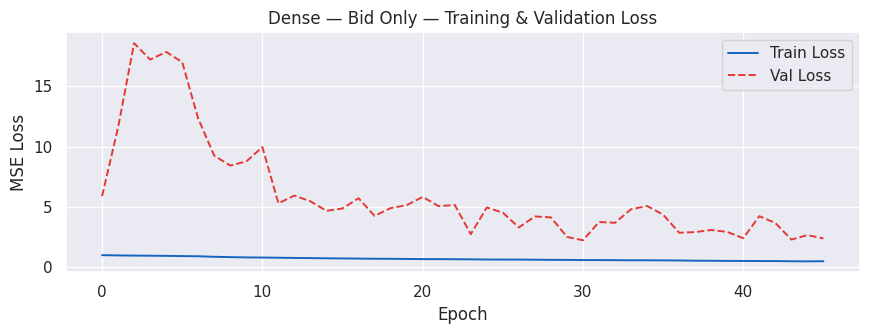

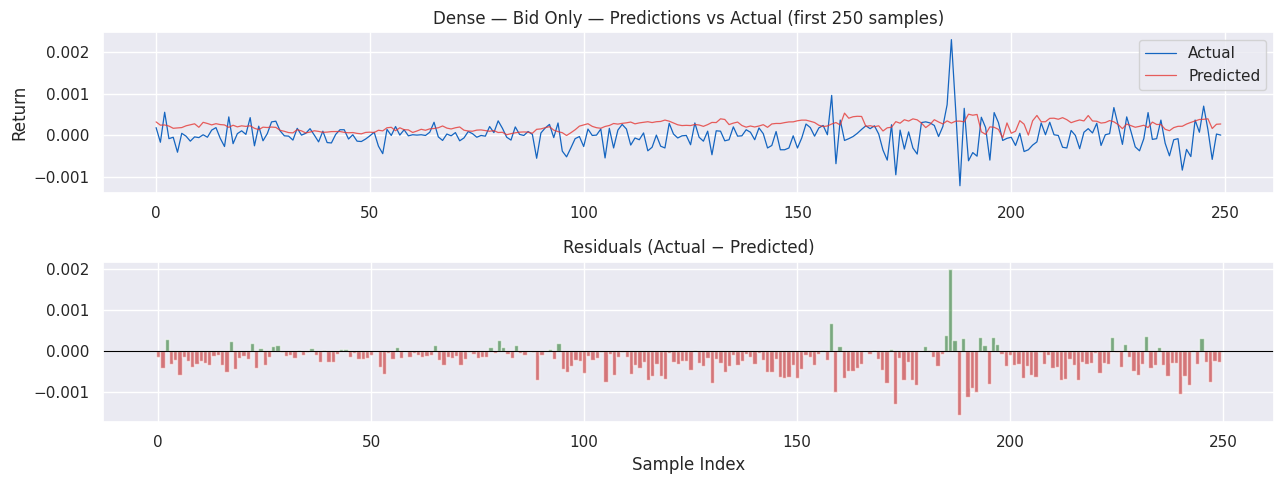


--- LSTM (Bid Only) ---


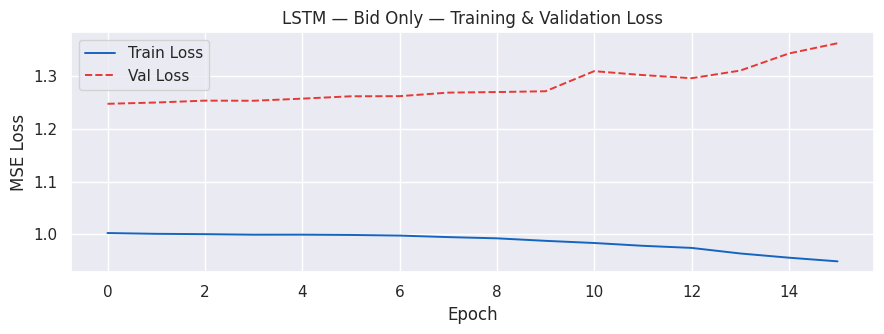

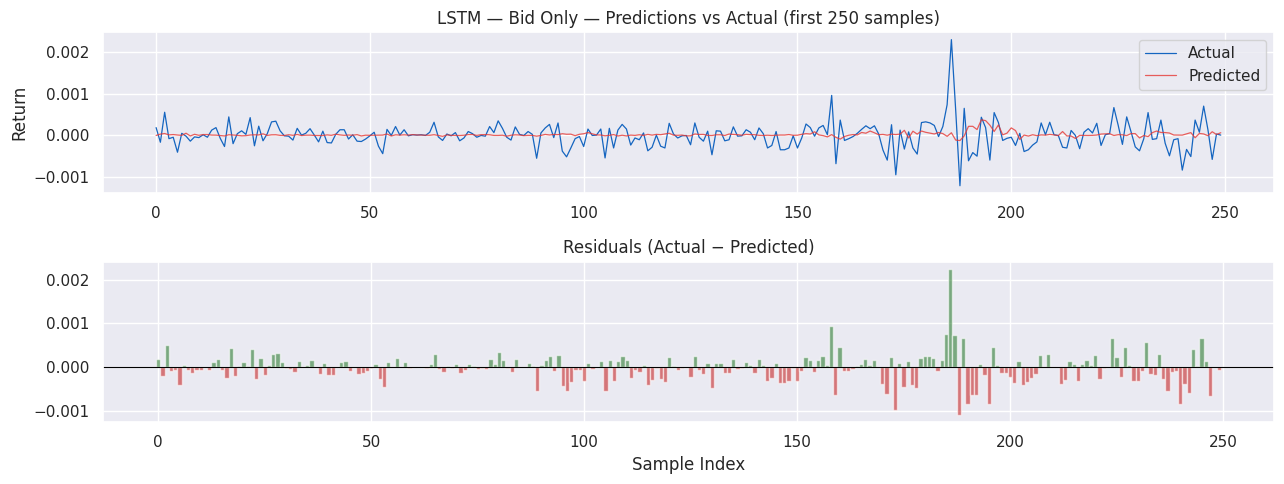


--- GRU (Bid Only) ---


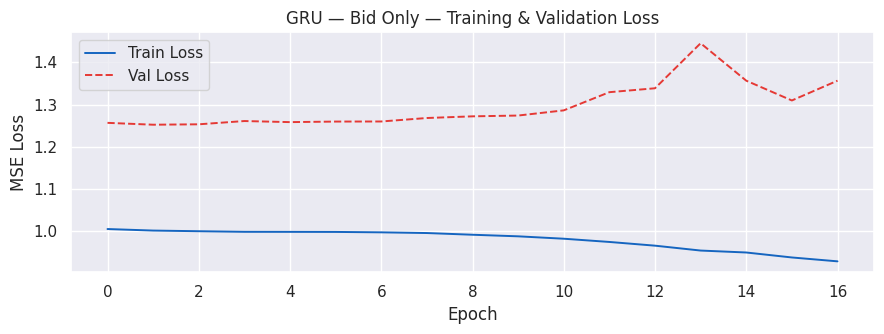

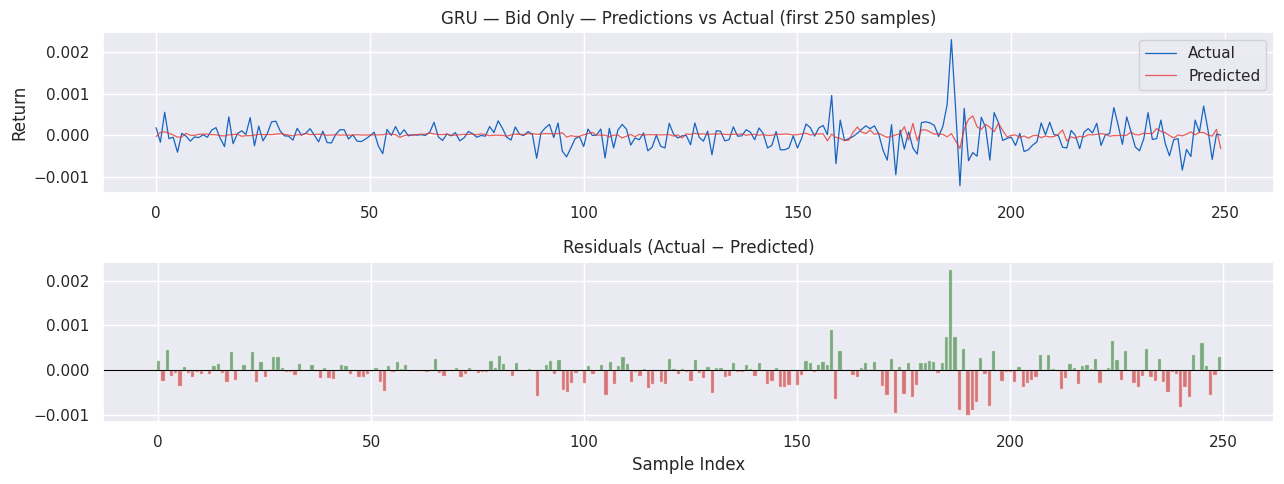


--- Transformer (Bid Only) ---


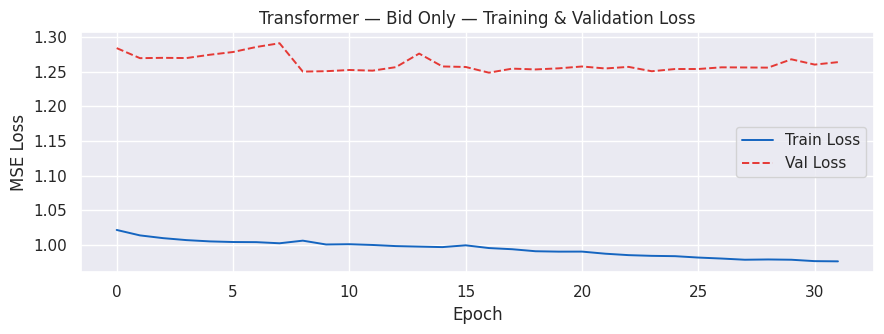

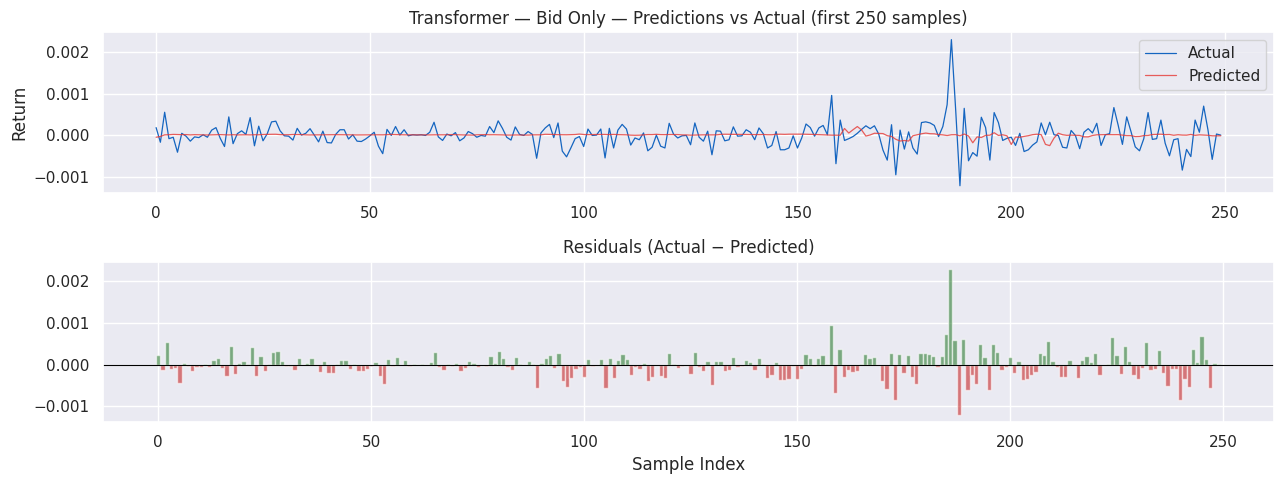

In [23]:
# WHAT: Plot training loss curves and prediction charts for all four
#       models in the Bid-only run.
# WHY:  Loss curves reveal whether each model converged smoothly,
#       stopped early, or overfit. Prediction charts show the quality
#       of the fit on the held-out test period visually, complementing
#       the numeric metrics.
# HOW:  plot_loss() and plot_predictions() are called for each model
#       using the shared function definitions from Section 5.

for model_name in ["Dense", "LSTM", "GRU", "Transformer"]:
    print(f"\n--- {model_name} (Bid Only) ---")
    plot_loss(histories_bid[model_name], f"{model_name} — Bid Only")
    plot_predictions(results_bid[model_name]["y_true"],
                     results_bid[model_name]["y_pred"],
                     f"{model_name} — Bid Only")


## Section 9 — Run 2: Ask-Only Data

In [24]:
# WHAT: Execute Run 2 — train all four models using only Ask price
#       features and evaluate on the held-out test set.
# WHY:  Ask prices are consistently higher than Bid prices by exactly
#       the spread amount. If Ask-only models produce metrics similar
#       to Bid-only models, it confirms that the two streams carry
#       equivalent directional information and that the spread
#       (their difference) is the additional signal only accessible
#       by combining both. If one consistently outperforms the other,
#       it reveals an asymmetry in liquidity information.
# HOW:  run_experiment() receives the Ask-only cleaned DataFrame,
#       the Ask feature column list, and the Ask target column.

results_ask, histories_ask = run_experiment(
    df_ask_clean, ask_features, "target_ask", "RUN 2 — ASK ONLY"
)



  RUN 2 — ASK ONLY
  Split → Train:25,874 | Val:5,545 | Test:5,545
  Train seqs: (25854, 20, 17) | Val: (5525, 20, 17) | Test: (5525, 20, 17)

  [1/4] Dense (MLP)
    Ep   1 | Train: 0.989285 | Val: 4.698057 | LR: 1.00e-03
    Ep  10 | Train: 0.825816 | Val: 5.056522 | LR: 1.00e-03
    Ep  20 | Train: 0.660596 | Val: 3.976912 | LR: 1.00e-03
    Ep  30 | Train: 0.538063 | Val: 5.716399 | LR: 2.50e-04
    Early stop at epoch 33
    RMSE=0.000452 | DA=48.63%

  [2/4] LSTM
    Ep   1 | Train: 1.001670 | Val: 1.260084 | LR: 1.00e-03
    Ep  10 | Train: 0.985397 | Val: 1.284416 | LR: 5.00e-04
    Early stop at epoch 17
    RMSE=0.000344 | DA=51.20%

  [3/4] GRU (hyperparameter search)
    Config: hidden=64 lr=0.001
    Ep   1 | Train: 1.004189 | Val: 1.258367 | LR: 1.00e-03
    Ep  10 | Train: 0.991974 | Val: 1.277427 | LR: 5.00e-04
    Early stop at epoch 16
    Config: hidden=128 lr=0.001
    Ep   1 | Train: 1.006892 | Val: 1.265855 | LR: 1.00e-03
    Ep  10 | Train: 0.985763 | Val: 1.315


--- Dense (Ask Only) ---


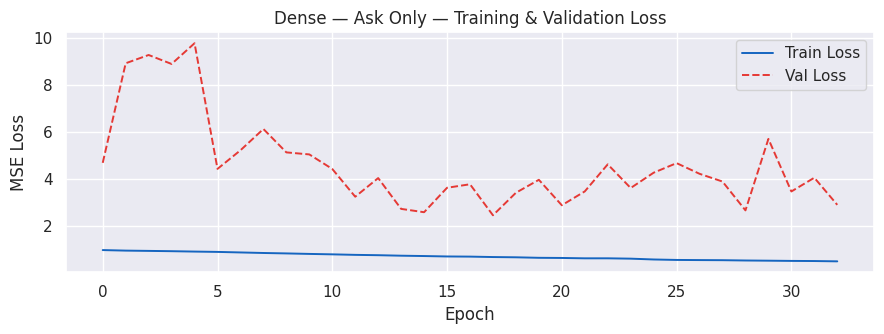

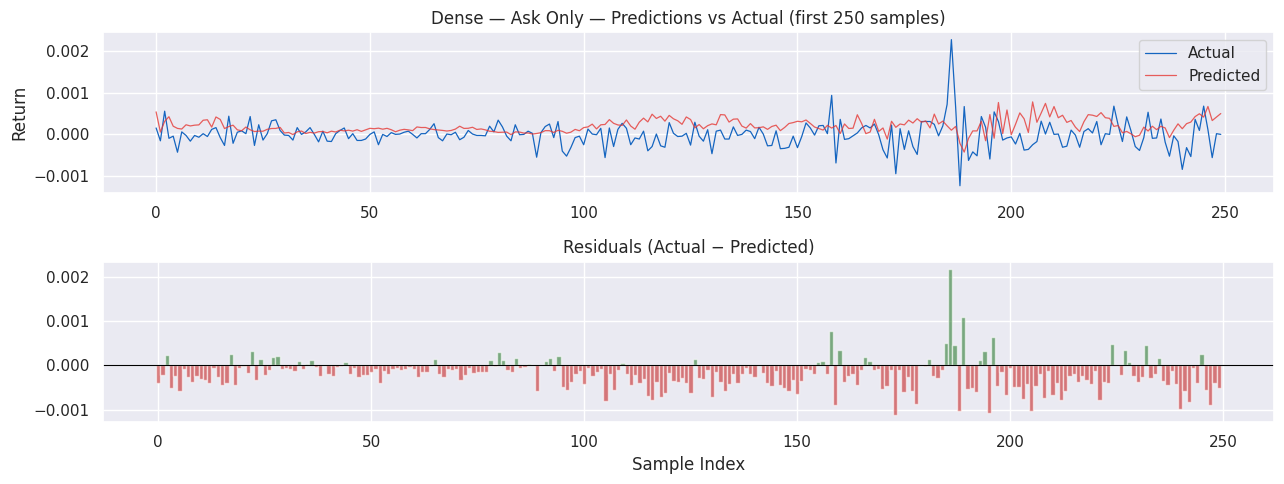


--- LSTM (Ask Only) ---


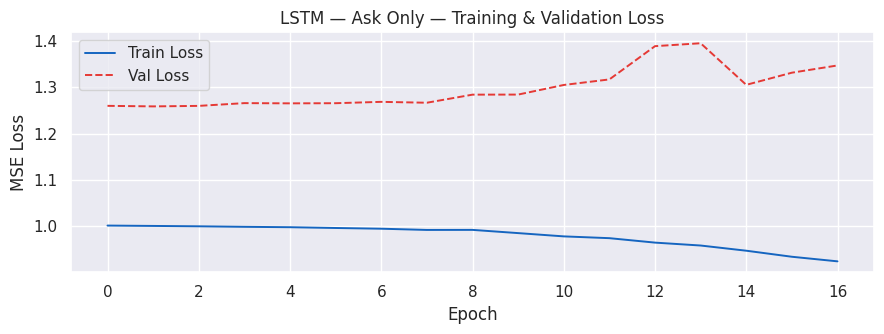

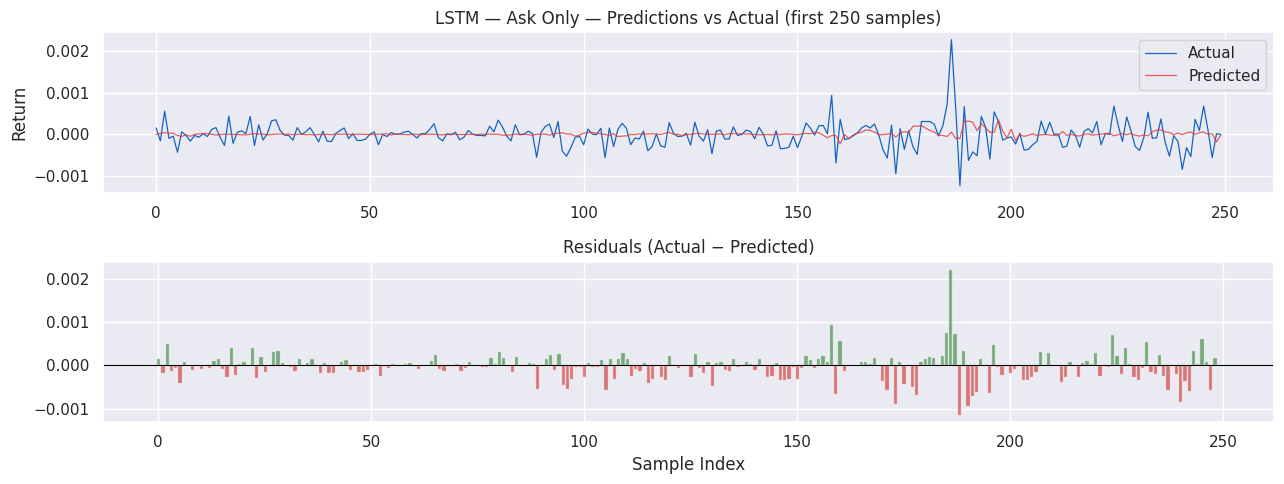


--- GRU (Ask Only) ---


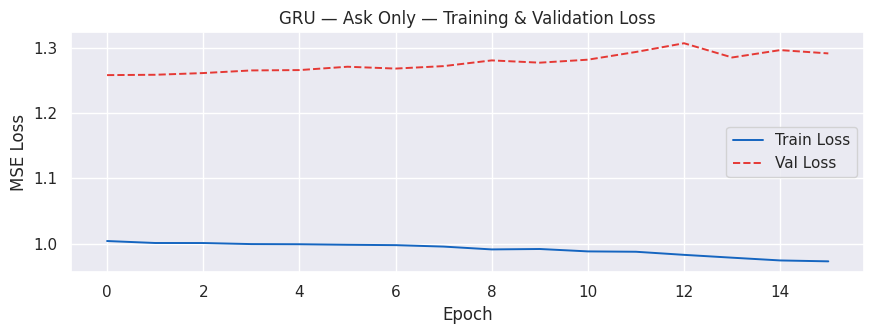

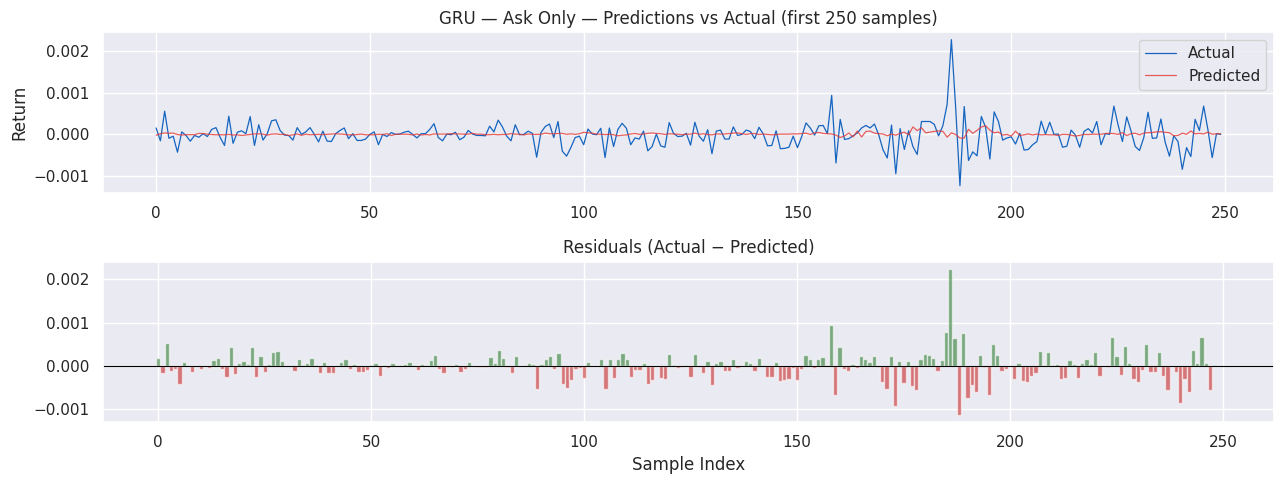


--- Transformer (Ask Only) ---


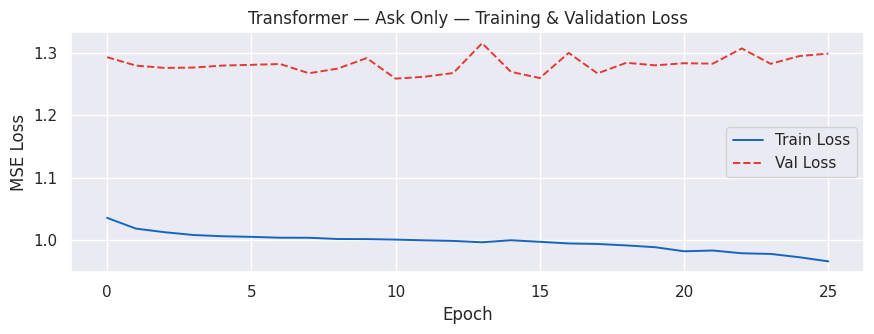

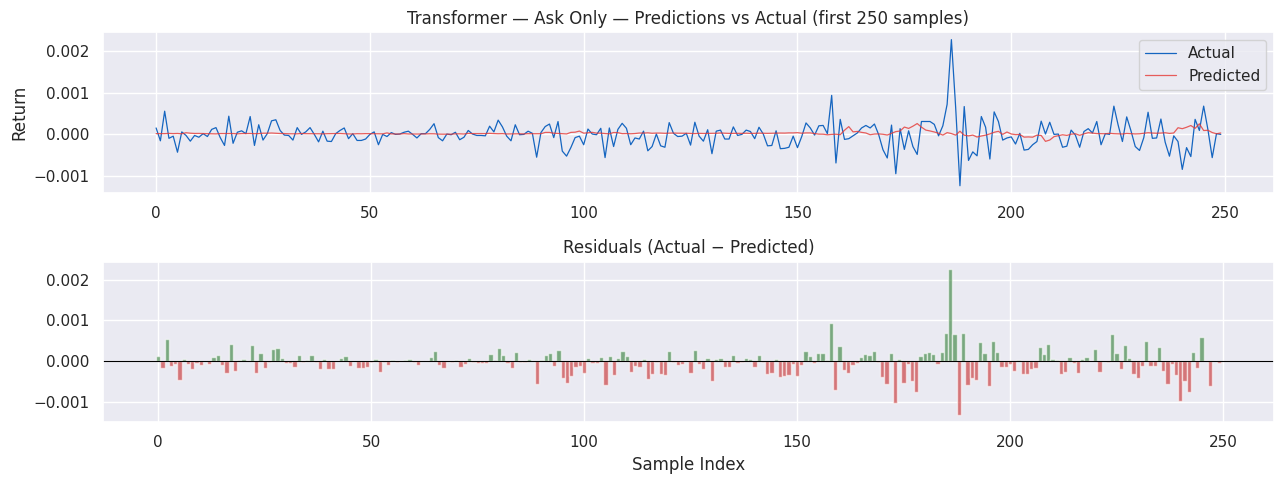

In [25]:
for model_name in ["Dense", "LSTM", "GRU", "Transformer"]:
    print(f"\n--- {model_name} (Ask Only) ---")
    plot_loss(histories_ask[model_name], f"{model_name} — Ask Only")
    plot_predictions(results_ask[model_name]["y_true"],
                     results_ask[model_name]["y_pred"],
                     f"{model_name} — Ask Only")


## Section 10 — Run 3: Combined Bid + Ask Data

In [26]:
# WHAT: Execute Run 3 — train all four models using the full combined
#       feature set including mid-price, spread, spread lags, and
#       volume ratio.
# WHY:  The combined feature set provides information that neither
#       single stream can produce: the mid-price (unbiased fair value),
#       the spread in pips (direct liquidity measure), spread lags
#       (recent liquidity trend), and the bid/ask volume ratio (order
#       flow imbalance). If these features carry predictive signal,
#       Run 3 metrics will be measurably better than Runs 1 and 2.
#       This is the central hypothesis of the three-run design.
# HOW:  run_experiment() receives the combined cleaned DataFrame,
#       the combined feature list (which is longer than Runs 1/2),
#       and the mid-price target column.

results_comb, histories_comb = run_experiment(
    df_comb_clean, combined_features, "target_mid", "RUN 3 — COMBINED BID + ASK"
)



  RUN 3 — COMBINED BID + ASK
  Split → Train:25,874 | Val:5,545 | Test:5,545
  Train seqs: (25854, 20, 23) | Val: (5525, 20, 23) | Test: (5525, 20, 23)

  [1/4] Dense (MLP)
    Ep   1 | Train: 0.986526 | Val: 5.596774 | LR: 1.00e-03
    Ep  10 | Train: 0.756358 | Val: 7.835679 | LR: 5.00e-04
    Ep  20 | Train: 0.623798 | Val: 4.228002 | LR: 5.00e-04
    Ep  30 | Train: 0.519406 | Val: 1.938614 | LR: 2.50e-04
    Ep  40 | Train: 0.469433 | Val: 1.816729 | LR: 1.25e-04
    Ep  50 | Train: 0.439691 | Val: 1.820871 | LR: 6.25e-05
    RMSE=0.000397 | DA=50.06%

  [2/4] LSTM
    Ep   1 | Train: 1.001937 | Val: 1.256427 | LR: 1.00e-03
    Ep  10 | Train: 0.983692 | Val: 1.303677 | LR: 5.00e-04
    Early stop at epoch 17
    RMSE=0.000345 | DA=49.94%

  [3/4] GRU (hyperparameter search)
    Config: hidden=64 lr=0.001
    Ep   1 | Train: 1.007925 | Val: 1.260415 | LR: 1.00e-03
    Ep  10 | Train: 0.990652 | Val: 1.278523 | LR: 5.00e-04
    Early stop at epoch 17
    Config: hidden=128 lr=0.00


--- Dense (Combined) ---


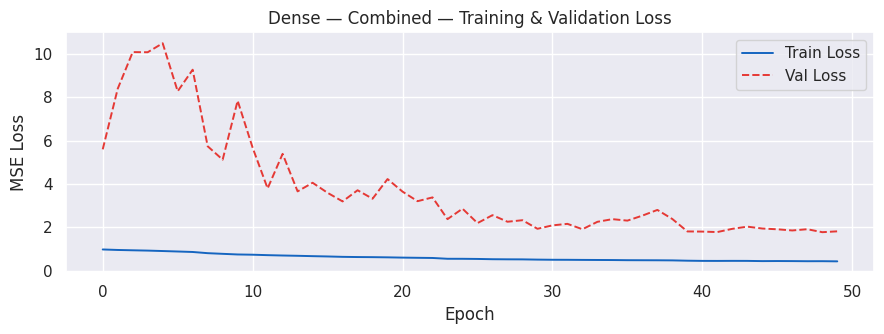

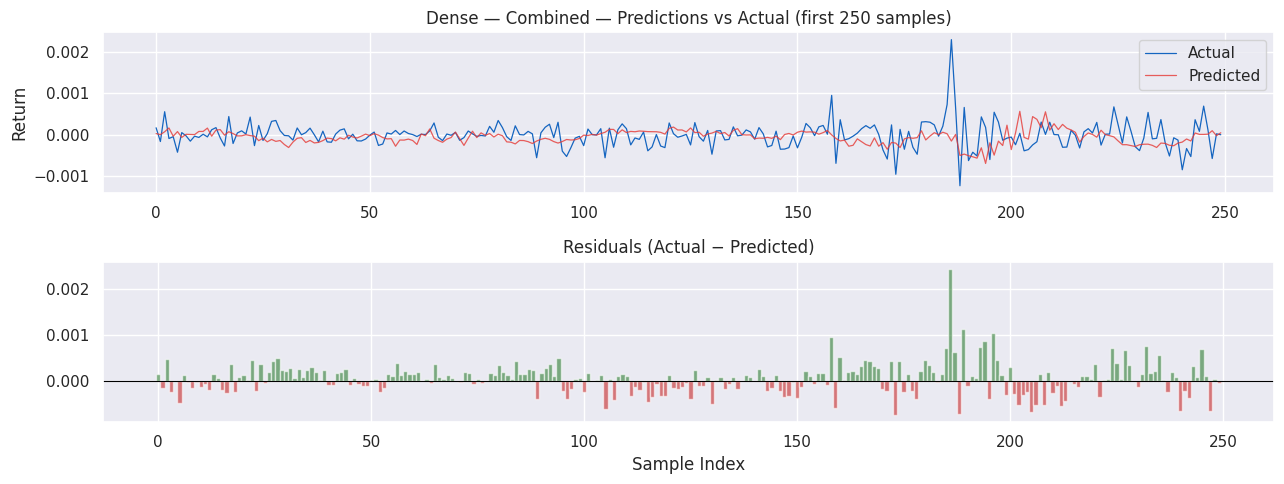


--- LSTM (Combined) ---


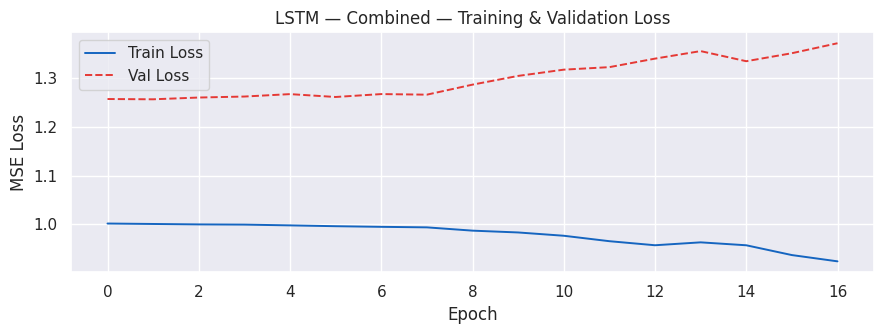

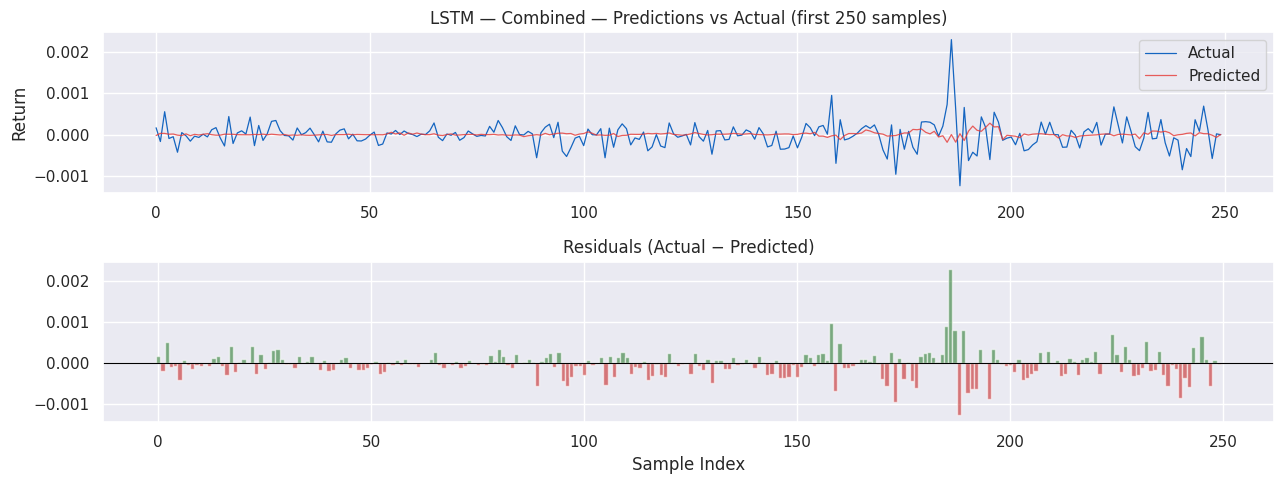


--- GRU (Combined) ---


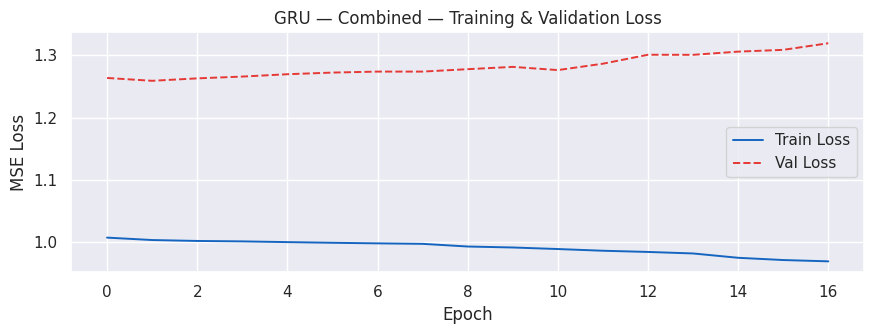

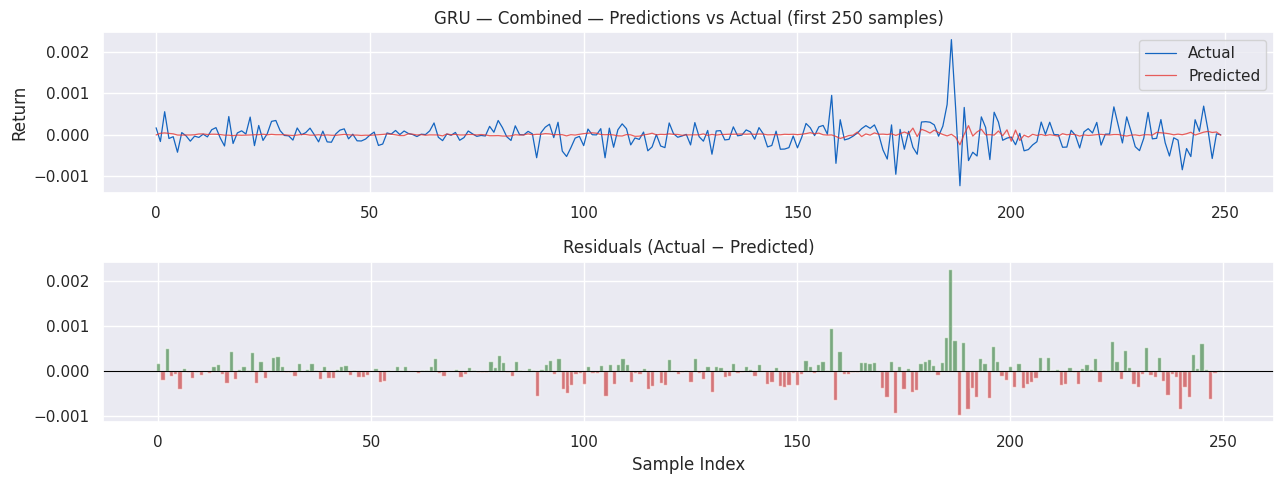


--- Transformer (Combined) ---


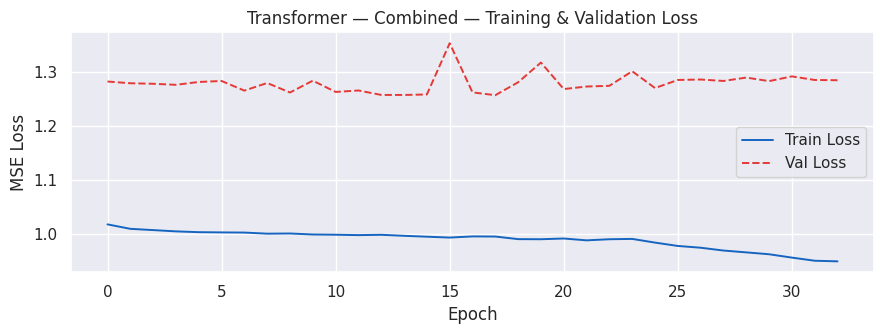

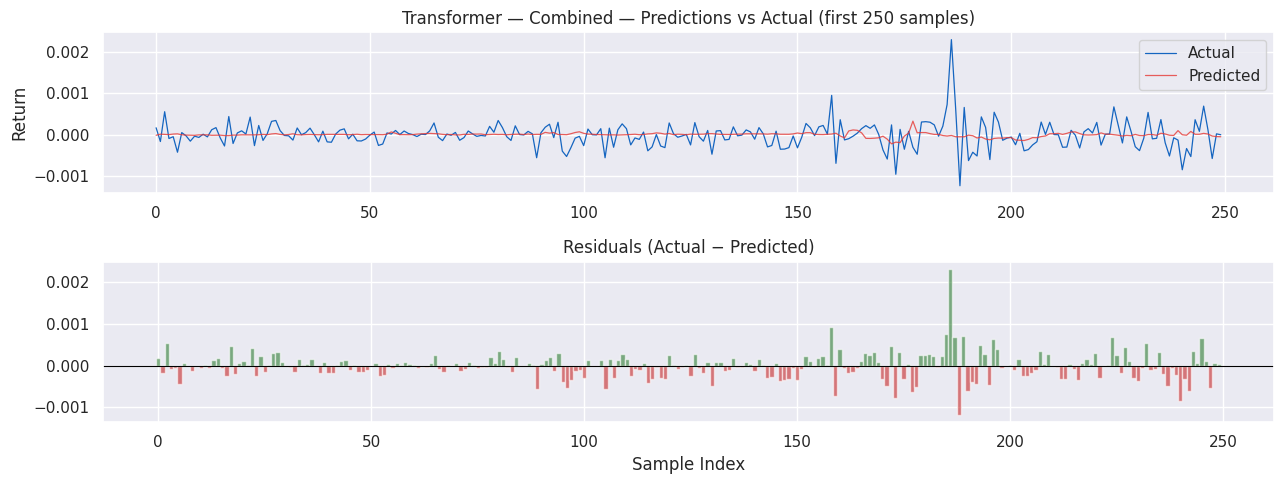

In [27]:
for model_name in ["Dense", "LSTM", "GRU", "Transformer"]:
    print(f"\n--- {model_name} (Combined) ---")
    plot_loss(histories_comb[model_name], f"{model_name} — Combined")
    plot_predictions(results_comb[model_name]["y_true"],
                     results_comb[model_name]["y_pred"],
                     f"{model_name} — Combined")


## Section 11 — Final Comparison & Advanced Visualisations

In [28]:
# WHAT: Build a master comparison table covering all 12 model/run
#       combinations across five metrics.
# WHY:  A single consolidated table is the most direct way to answer
#       the central research question: does combining Bid and Ask data
#       improve forecasting performance across all four model architectures?
#       Sorting by RMSE within each run reveals which model benefits
#       most from the richer feature set.
# HOW:  Three nested loops over runs and models extract metrics from
#       the results dictionaries into a flat list of records that
#       pd.DataFrame converts into a table.

runs = {
    "Bid Only":  results_bid,
    "Ask Only":  results_ask,
    "Combined":  results_comb,
}

records = []
for run_name, res_dict in runs.items():
    for model_name, metrics in res_dict.items():
        records.append({
            "Run":   run_name,
            "Model": model_name,
            "MAE":   round(metrics["MAE"],  6),
            "RMSE":  round(metrics["RMSE"], 6),
            "R²":    round(metrics["R2"],   4),
            "DA %":  round(metrics["DA%"],  2),
        })

master_df = pd.DataFrame(records)

print("=" * 75)
print("MASTER COMPARISON TABLE — All Runs × All Models (sorted by RMSE per Run)")
print("=" * 75)
for run_name in ["Bid Only", "Ask Only", "Combined"]:
    subset = master_df[master_df["Run"] == run_name].sort_values("RMSE")
    print(f"\n{run_name}:")
    print(subset.to_string(index=False))
print("=" * 75)


MASTER COMPARISON TABLE — All Runs × All Models (sorted by RMSE per Run)

Bid Only:
     Run       Model      MAE     RMSE      R²  DA %
Bid Only Transformer 0.000218 0.000338 -0.0131 48.49
Bid Only        LSTM 0.000220 0.000341 -0.0297 49.07
Bid Only         GRU 0.000222 0.000344 -0.0463 50.05
Bid Only       Dense 0.000370 0.000480 -1.0408 48.24

Ask Only:
     Run       Model      MAE     RMSE      R²  DA %
Ask Only         GRU 0.000217 0.000339 -0.0120 51.22
Ask Only Transformer 0.000223 0.000343 -0.0396 49.32
Ask Only        LSTM 0.000221 0.000344 -0.0449 51.20
Ask Only       Dense 0.000327 0.000452 -0.8066 48.63

Combined:
     Run       Model      MAE     RMSE      R²  DA %
Combined         GRU 0.000217 0.000338 -0.0119 50.75
Combined Transformer 0.000219 0.000339 -0.0209 49.94
Combined        LSTM 0.000222 0.000345 -0.0529 49.94
Combined       Dense 0.000272 0.000397 -0.3993 50.06


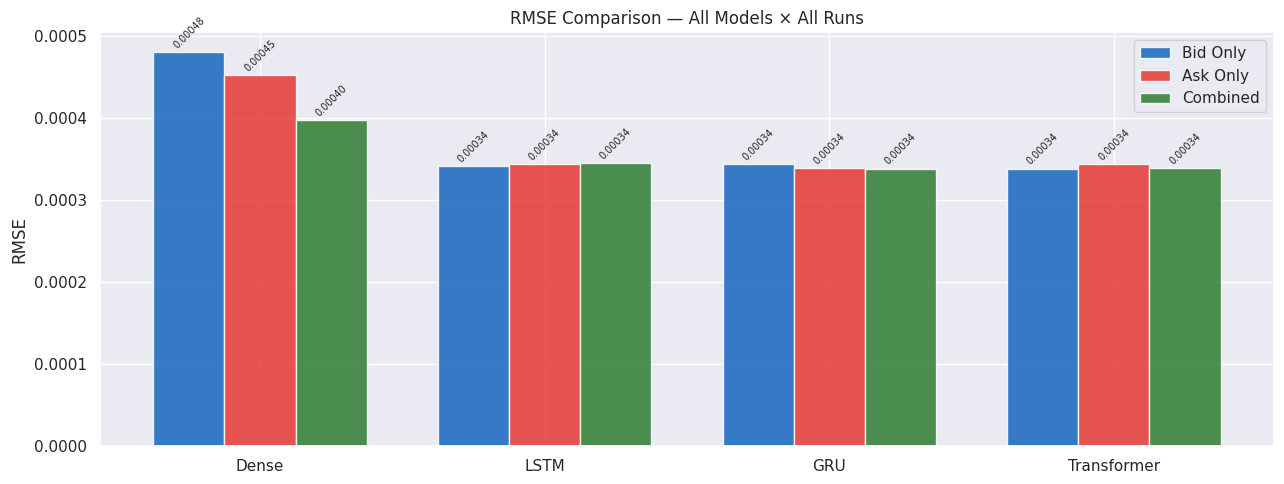

In [29]:
# WHAT: Plot a grouped bar chart of RMSE for all models across the
#       three runs, with models on the x-axis and runs as bar groups.
# WHY:  This chart directly answers the question "does the Combined run
#       produce lower RMSE than Bid-only or Ask-only for every model?"
#       If the Combined bars are consistently shorter, the hypothesis
#       is confirmed. If only some models improve, it reveals which
#       architectures can exploit the additional microstructure features.
# HOW:  Four model groups on the x-axis. Three bars per group (one per
#       run) using distinct colours. Bar labels show the exact values.

models_list = ["Dense", "LSTM", "GRU", "Transformer"]
run_names   = ["Bid Only", "Ask Only", "Combined"]
run_colours = ["#1565C0", "#E53935", "#2E7D32"]

x = np.arange(len(models_list))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (run_name, col) in enumerate(zip(run_names, run_colours)):
    vals = [master_df[(master_df["Run"]==run_name) &
                      (master_df["Model"]==m)]["RMSE"].values[0]
            for m in models_list]
    bars = ax.bar(x + (i-1)*w, vals, w, label=run_name,
                  color=col, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.000002,
                f"{v:.5f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=11)
ax.set_ylabel("RMSE"); ax.set_title("RMSE Comparison — All Models × All Runs")
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


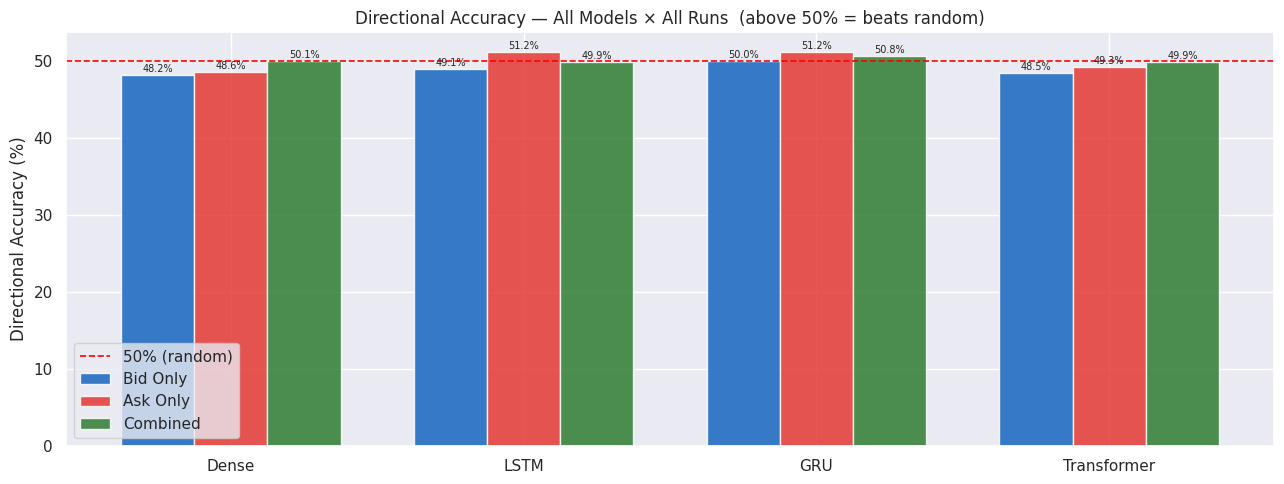

In [30]:
# WHAT: Plot Directional Accuracy for all models across the three runs.
# WHY:  DA is the most practically relevant metric for trading — it
#       measures whether the model correctly predicts the sign of the
#       next return. A DA above 50% beats a random coin flip.
#       Unlike RMSE, DA is directly interpretable in economic terms:
#       a strategy that trades in the predicted direction on every bar
#       profits when DA > 50% (before transaction costs).
#       Comparing DA across runs shows whether the additional features
#       in Run 3 improve trading signal quality, not just error magnitude.
# HOW:  Same grouped bar structure as the RMSE chart. A red dashed
#       line at 50% marks the random-chance threshold.

fig, ax = plt.subplots(figsize=(13, 5))
for i, (run_name, col) in enumerate(zip(run_names, run_colours)):
    vals = [master_df[(master_df["Run"]==run_name) &
                      (master_df["Model"]==m)]["DA %"].values[0]
            for m in models_list]
    bars = ax.bar(x + (i-1)*w, vals, w, label=run_name,
                  color=col, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

ax.axhline(50, color="red", lw=1.2, linestyle="--", label="50% (random)")
ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=11)
ax.set_ylabel("Directional Accuracy (%)")
ax.set_title("Directional Accuracy — All Models × All Runs  (above 50% = beats random)")
ax.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/da_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


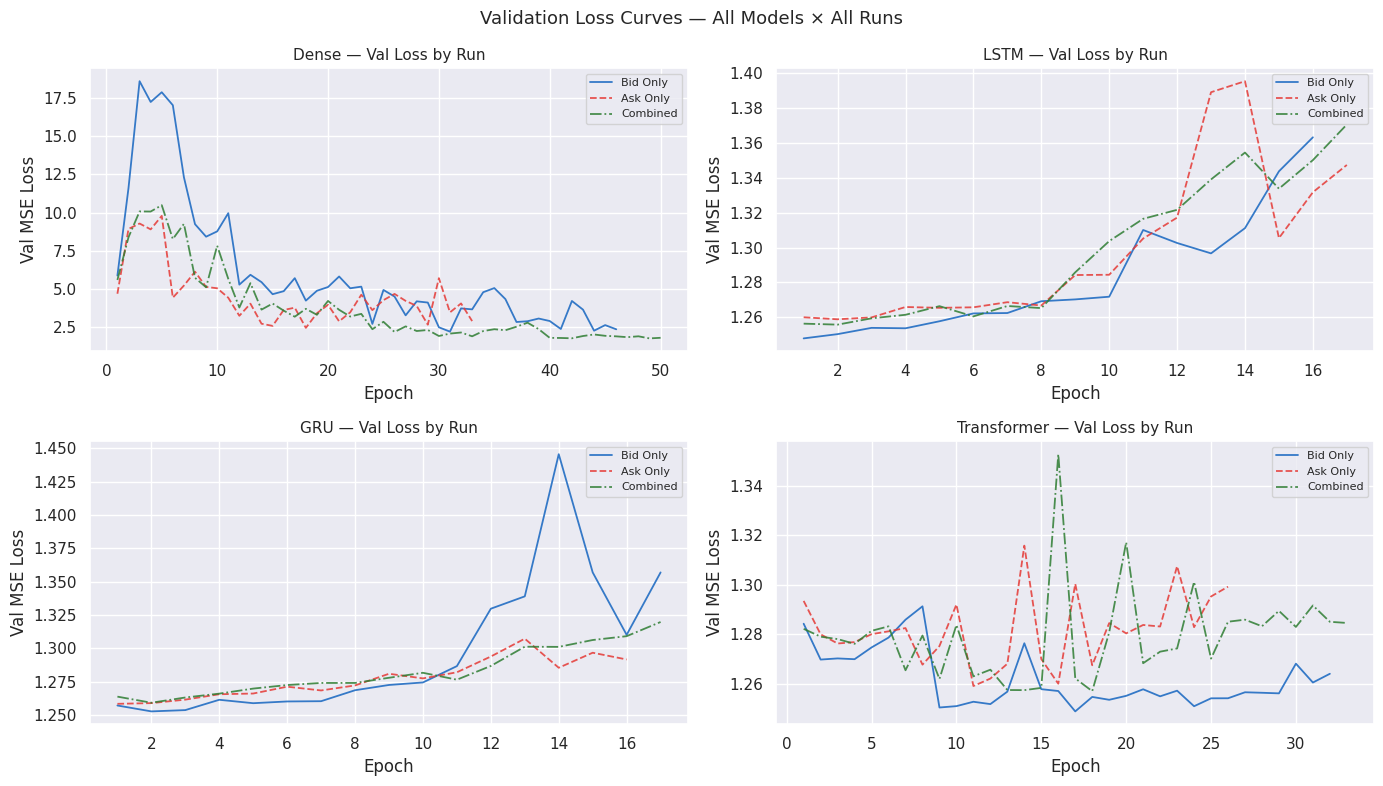

In [31]:
# WHAT: Overlay the validation loss curves of all three runs for each
#       model on a 2×2 subplot grid.
# WHY:  Overlaying curves from the same model across three runs shows
#       how quickly and smoothly each run converges. If the Combined
#       run converges to a lower validation loss in fewer epochs, it
#       demonstrates that the richer feature set not only produces
#       better final metrics but also makes training more efficient.
# HOW:  A 2×2 subplot grid with one panel per model. Three curves per
#       panel (one per run). Line styles differentiate runs visually.

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
linestyles = ["-", "--", "-."]

for ax, model_name in zip(axes, models_list):
    for (run_name, col, ls) in zip(run_names, run_colours, linestyles):
        hist_map = {"Bid Only": histories_bid,
                    "Ask Only": histories_ask,
                    "Combined": histories_comb}
        h = hist_map[run_name][model_name]["val"]
        ax.plot(range(1, len(h)+1), h, color=col, lw=1.3,
                ls=ls, label=run_name, alpha=0.85)
    ax.set_title(f"{model_name} — Val Loss by Run", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Val MSE Loss")
    ax.legend(fontsize=8)

plt.suptitle("Validation Loss Curves — All Models × All Runs", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/val_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


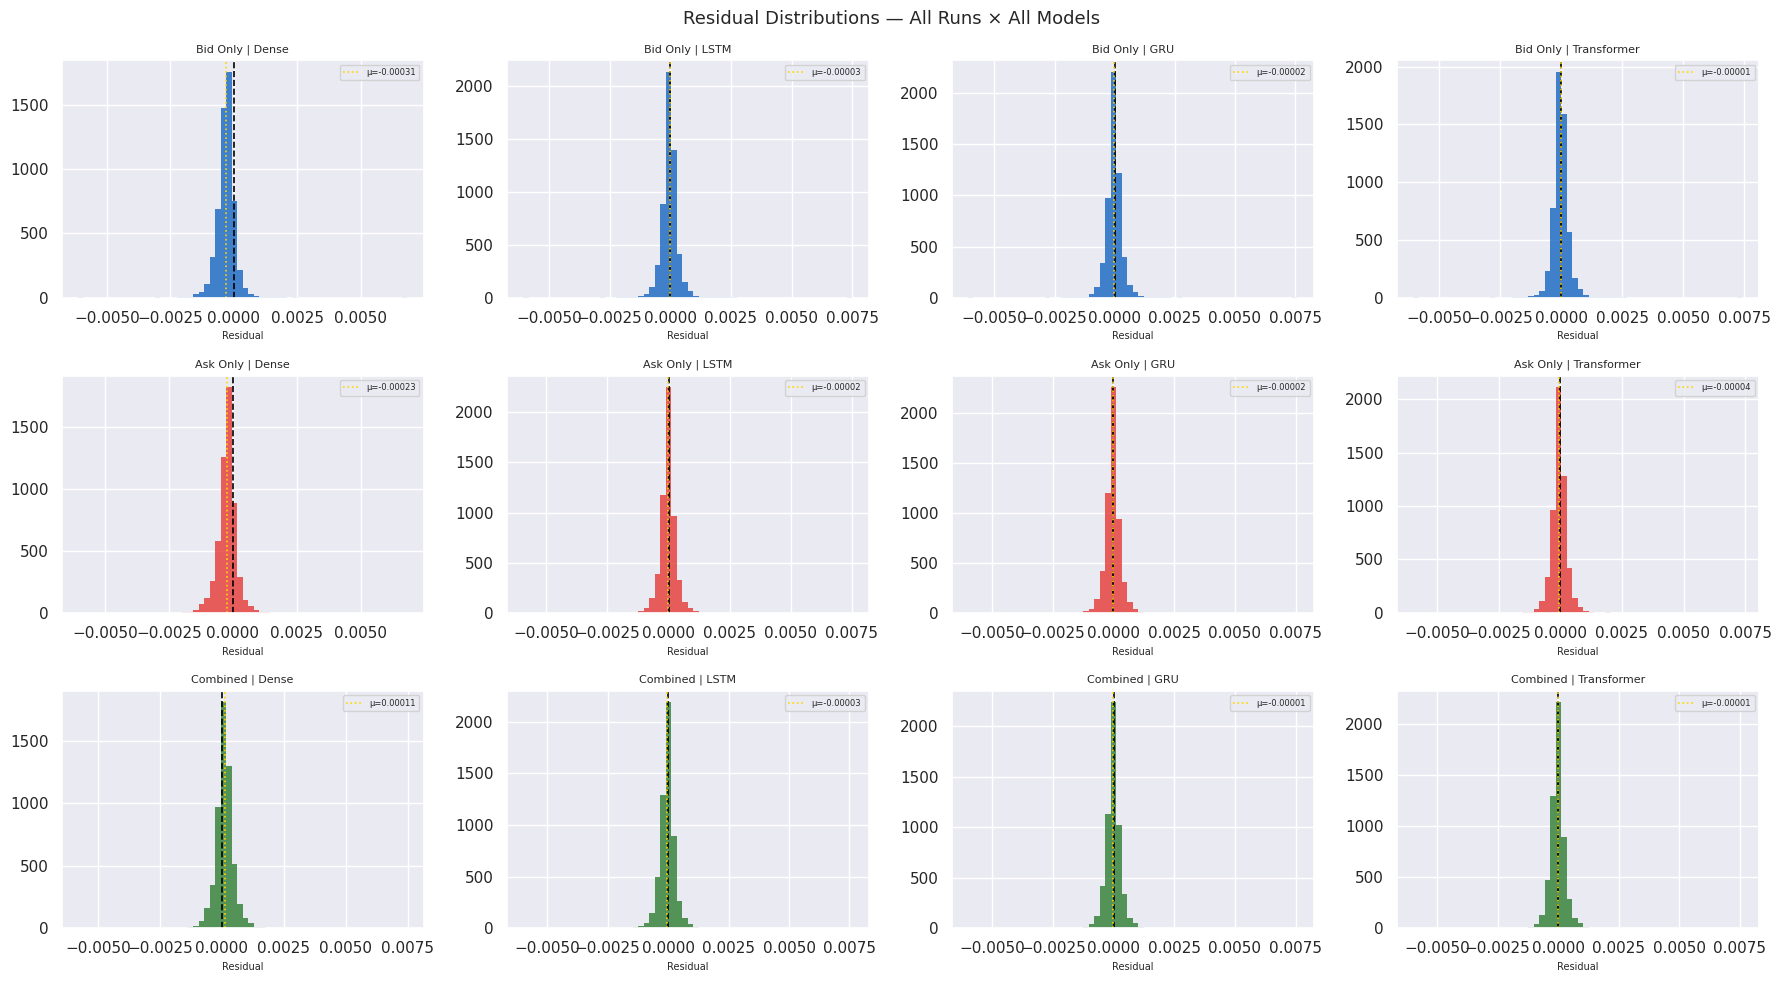

In [32]:
# WHAT: Plot residual distributions for all 12 model/run combinations
#       in a 3×4 grid (rows = runs, columns = models).
# WHY:  A well-calibrated model produces residuals centred at zero with
#       an approximately normal shape. A mean far from zero indicates
#       systematic bias. Comparing residual shapes across runs for the
#       same model shows whether the additional features in Run 3 reduce
#       bias or heavy tails, complementing the metric comparison.
# HOW:  12 subplots arranged in 3 rows (one per run) × 4 columns
#       (one per model). Each subplot shows a histogram of test residuals
#       with a vertical line at zero and at the mean.

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharey=False)
run_results_map = {
    "Bid Only": results_bid,
    "Ask Only": results_ask,
    "Combined": results_comb,
}

for row, (run_name, res_dict) in enumerate(run_results_map.items()):
    for col, model_name in enumerate(models_list):
        ax  = axes[row, col]
        res = res_dict[model_name]["y_true"] - res_dict[model_name]["y_pred"]
        ax.hist(res, bins=60, color=run_colours[row],
                edgecolor="none", alpha=0.8)
        ax.axvline(0,          color="black", lw=1.2, linestyle="--")
        ax.axvline(res.mean(), color="gold",  lw=1.2, linestyle=":",
                   label=f"μ={res.mean():.5f}")
        ax.set_title(f"{run_name} | {model_name}", fontsize=8)
        ax.set_xlabel("Residual", fontsize=7)
        ax.legend(fontsize=6)

plt.suptitle("Residual Distributions — All Runs × All Models", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/residual_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


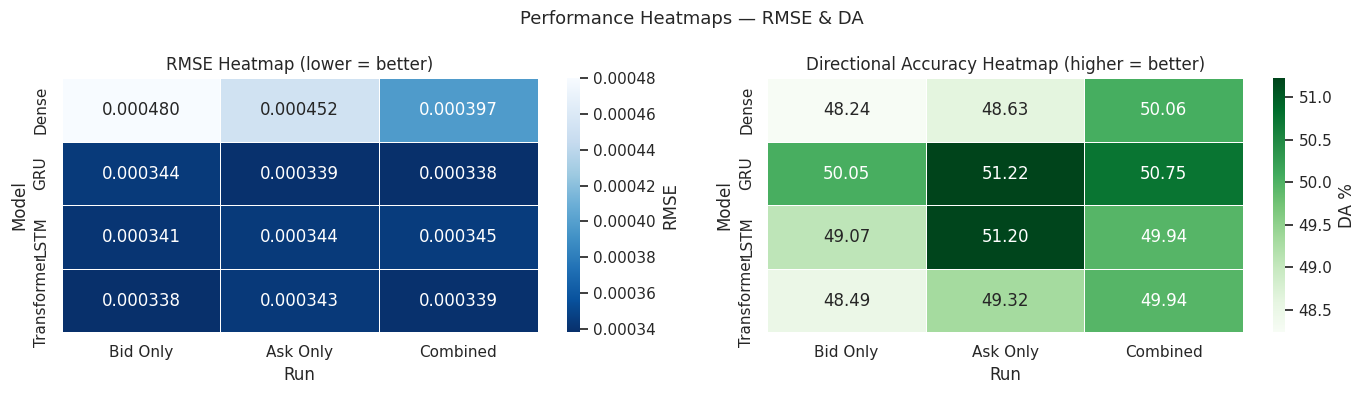

In [33]:
# WHAT: Plot a heatmap of RMSE values with runs on one axis and
#       models on the other, colour-coded so lower is darker.
# WHY:  A heatmap condenses all 12 RMSE values into one chart where
#       patterns are immediately visible — dark columns indicate models
#       that perform well across all runs, dark rows indicate runs that
#       consistently produce better results, and individual dark cells
#       show the best model/run combinations.
# HOW:  The master_df is pivoted with Model as rows and Run as columns.
#       sns.heatmap with annot=True displays the numeric value inside
#       each cell. fmt=".6f" shows six decimal places for RMSE.

rmse_pivot = master_df.pivot(index="Model", columns="Run", values="RMSE")
rmse_pivot = rmse_pivot[["Bid Only", "Ask Only", "Combined"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(rmse_pivot, annot=True, fmt=".6f", cmap="Blues_r",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "RMSE"})
axes[0].set_title("RMSE Heatmap (lower = better)")

da_pivot = master_df.pivot(index="Model", columns="Run", values="DA %")
da_pivot = da_pivot[["Bid Only", "Ask Only", "Combined"]]

sns.heatmap(da_pivot, annot=True, fmt=".2f", cmap="Greens",
            linewidths=0.5, ax=axes[1], cbar_kws={"label": "DA %"})
axes[1].set_title("Directional Accuracy Heatmap (higher = better)")

plt.suptitle("Performance Heatmaps — RMSE & DA", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


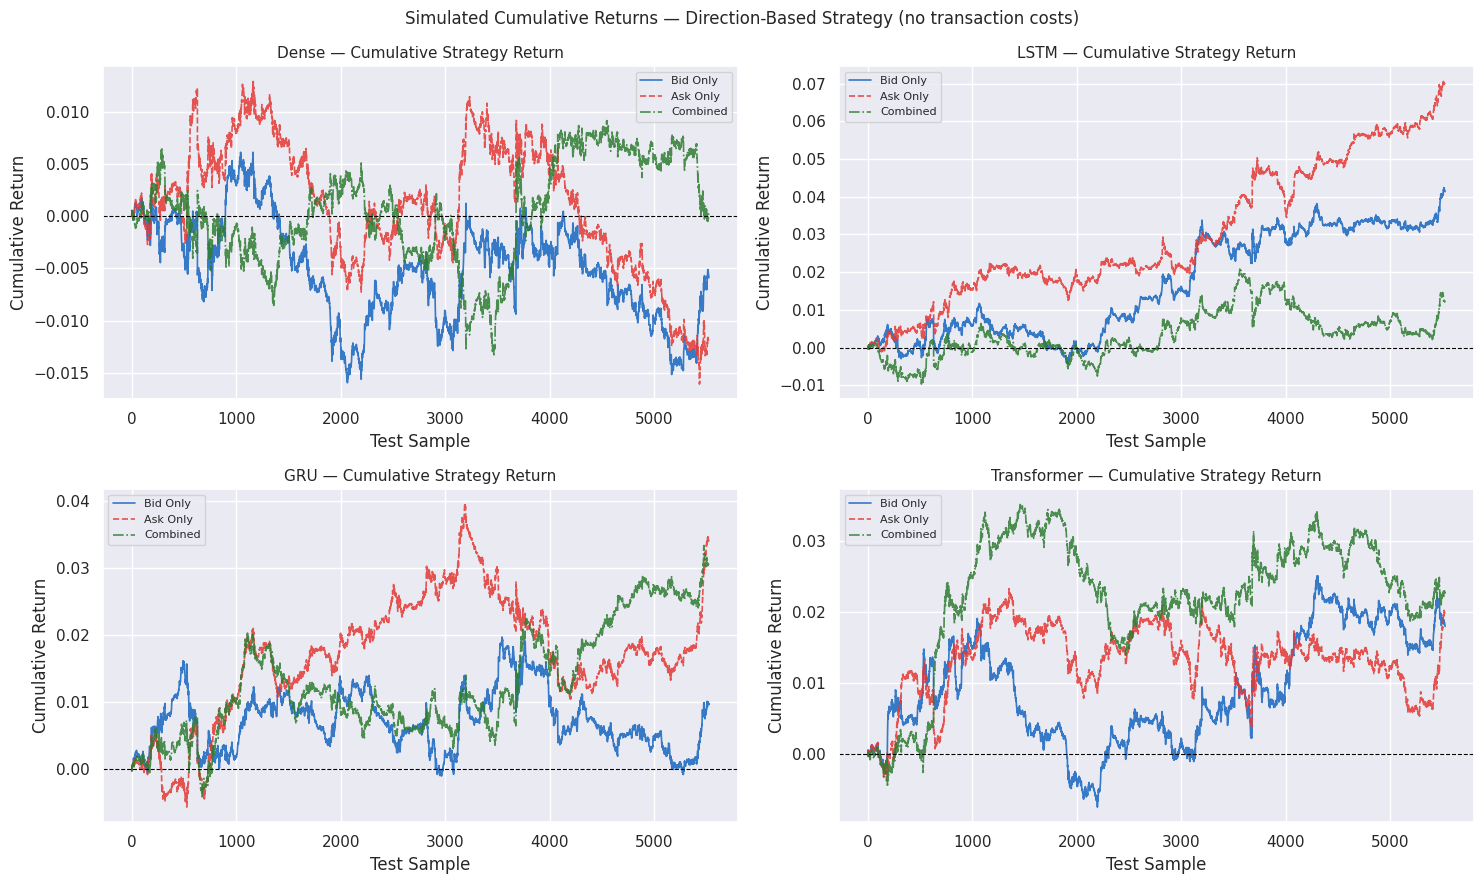

Note: Simplified backtest only. No transaction costs or slippage included.


In [34]:
# WHAT: Simulate a direction-based trading strategy for every model/run
#       and plot cumulative returns for all 12 combinations.
# WHY:  Cumulative return simulation translates model predictions into
#       economic outcomes — the question a trader would actually ask.
#       A model that gets direction right on large moves produces higher
#       cumulative returns even if its RMSE is not the lowest. Comparing
#       all 12 strategies shows whether the Combined run produces
#       consistently more profitable strategies across all model types.
# HOW:  At each test bar, the strategy takes a long position (+1) if
#       the model predicts a positive return and a short position (-1)
#       if it predicts negative. The strategy return is prediction sign
#       times actual return. np.cumsum accumulates across the test period.

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, model_name in zip(axes, models_list):
    for (run_name, col, ls) in zip(run_names, run_colours, linestyles):
        res_dict = {"Bid Only": results_bid,
                    "Ask Only": results_ask,
                    "Combined": results_comb}[run_name]
        r       = res_dict[model_name]
        strat   = np.sign(r["y_pred"]) * r["y_true"]
        cum_ret = np.cumsum(strat)
        ax.plot(cum_ret, color=col, lw=1.2, ls=ls, label=run_name, alpha=0.85)

    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"{model_name} — Cumulative Strategy Return", fontsize=11)
    ax.set_xlabel("Test Sample"); ax.set_ylabel("Cumulative Return")
    ax.legend(fontsize=8)

plt.suptitle("Simulated Cumulative Returns — Direction-Based Strategy "
             "(no transaction costs)", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Note: Simplified backtest only. No transaction costs or slippage included.")


In [36]:
# WHAT: Print the final ranked summary identifying the single best
#       model/run combination and quantify the improvement of the
#       Combined run over the single-stream baselines.
# WHY:  A concise written summary provides the key takeaway that
#       supports the report's conclusions section. Quantifying the
#       improvement in percentage points makes the benefit of combining
#       Bid and Ask data concrete and defensible.
# HOW:  The best row is identified by minimum RMSE. The average RMSE
#       of Bid-only and Ask-only is compared to the best Combined RMSE.

best_row = master_df.sort_values("RMSE").iloc[0]

avg_bid_rmse  = master_df[master_df["Run"]=="Bid Only"]["RMSE"].mean()
avg_ask_rmse  = master_df[master_df["Run"]=="Ask Only"]["RMSE"].mean()
avg_comb_rmse = master_df[master_df["Run"]=="Combined"]["RMSE"].mean()

print("=" * 70)
print("                    FINAL SUMMARY")
print("=" * 70)
print(f"\nBest model/run:  {best_row['Model']} — {best_row['Run']}")
print(f"  RMSE           : {best_row['RMSE']:.6f}")
print(f"  DA             : {best_row['DA %']:.2f}%")
print(f"  R²             : {best_row['R²']:.4f}")

print(f"\nAverage RMSE across all models:")
print(f"  Bid Only  : {avg_bid_rmse:.6f}")
print(f"  Ask Only  : {avg_ask_rmse:.6f}")
print(f"  Combined  : {avg_comb_rmse:.6f}")

bid_improvement  = (avg_bid_rmse  - avg_comb_rmse) / avg_bid_rmse  * 100
ask_improvement  = (avg_ask_rmse  - avg_comb_rmse) / avg_ask_rmse  * 100
print(f"\nCombined vs Bid Only : {bid_improvement:+.2f}% RMSE reduction")
print(f"Combined vs Ask Only : {ask_improvement:+.2f}% RMSE reduction")

best_da_row = master_df.sort_values("DA %", ascending=False).iloc[0]
print(f"\nHighest DA:  {best_da_row['Model']} — {best_da_row['Run']} "
      f"({best_da_row['DA %']:.2f}%)")
print("=" * 70)

                    FINAL SUMMARY

Best model/run:  Transformer — Bid Only
  RMSE           : 0.000338
  DA             : 48.49%
  R²             : -0.0131

Average RMSE across all models:
  Bid Only  : 0.000376
  Ask Only  : 0.000370
  Combined  : 0.000355

Combined vs Bid Only : +5.59% RMSE reduction
Combined vs Ask Only : +3.99% RMSE reduction

Highest DA:  GRU — Ask Only (51.22%)
